<a href="https://colab.research.google.com/github/suphitchakh-web/Project_1/blob/main/Team06_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Amazon Reviews Analysis — Musical Instruments

## การนำเข้าข้อมูล

In [1]:
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os

BASE_PATH = "/content/drive/MyDrive/part_2"

REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Review file exists: False
Metadata file exists: False


## 1. Setup และการกำหนดค่าการวิเคราะห์

ในขั้นตอนนี้จะเตรียม Python libraries ที่จำเป็น กำหนดค่า RANDOM_SEED และ SAMPLE_N เพื่อให้การสุ่มข้อมูลสามารถทำซ้ำได้ รวมถึงกำหนดตำแหน่งของไฟล์ Review และ Product Metadata ที่ใช้ในการวิเคราะห์

ข้อมูลที่ใช้ประกอบด้วย
- Musical Instruments Review Data
- Musical Instruments Product Metadata

In [3]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

RANDOM_SEED = 42
SAMPLE_N = 50000
np.random.seed(RANDOM_SEED)

# เชื่อม Google Drive
drive.mount("/content/drive")

# ตำแหน่งโฟลเดอร์ Part 2
BASE_PATH = "/content/drive/MyDrive/part_2"

# ตำแหน่งไฟล์ข้อมูล
REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

# ตรวจสอบไฟล์
print("RANDOM_SEED =", RANDOM_SEED)
print("SAMPLE_N =", SAMPLE_N)
print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Mounted at /content/drive
RANDOM_SEED = 42
SAMPLE_N = 50000
Review file exists: True
Metadata file exists: True


## 2. ตรวจสอบโครงสร้างของข้อมูล

### 2.1 Review Data

In [4]:
review_preview = pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(review_preview))

print("\nColumns:")
print(review_preview.columns.tolist())

print("\nData types:")
print(review_preview.dtypes)

print("\nตัวอย่าง Review Data:")
display(review_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['user_id', 'parent_asin', 'rating', 'timestamp']

Data types:
user_id         object
parent_asin     object
rating         float64
timestamp        int64
dtype: object

ตัวอย่าง Review Data:


,user_id,parent_asin,rating,timestamp
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,1452650586000
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,1384912482000
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,1558567365290
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,1607055693671
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,1622595785255


### 2.2 Product Metadata

In [5]:
meta_preview = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(meta_preview))

print("\nColumns:")
print(meta_preview.columns.tolist())

print("\nData types:")
print(meta_preview.dtypes)

print("\nตัวอย่าง Product Metadata:")
display(meta_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object

ตัวอย่าง Product Metadata:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Musical Instruments,Pearl Export Lacquer EXL725S/C249 5-Piece New ...,4.2,22,[Item may ship in more than one box and may ar...,[Introducing the best selling drum set of all ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Best Selling Drum Set of All Time'...,Pearl,"[Musical Instruments, Drums & Percussion, Drum...","{'Item Weight': '33 pounds', 'Product Dimensio...",B01M4HO6RK,NaN
1,Musical Instruments,Behringer EUROPOWER EPQ900 Professional 900 Wa...,4.0,13,[2 x 390 Watts into 4 Ohms; 2 x 245 Watts into...,"[BEHRINGER EUROPOWER EPQ900, Professional 900-...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Behringer,"[Musical Instruments, Live Sound & Stage, Powe...","{'Item Weight': '10.8 pounds', 'Product Dimens...",B00508JFE4,NaN
2,Musical Instruments,Washburn Classical Series Acoustic Electric Cu...,3.6,15,[The Washburn is truly a professional instrume...,[C64SCE CLASSICAL GUITAR The cutaway allows ac...,399.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],Washburn,"[Musical Instruments, Guitars]","{'Item Weight': '5.98 pounds', 'Product Dimens...",B000S5JGMU,NaN
3,Musical Instruments,"VocoPro, plug in, Black, 21.00 x 21.00 x 23.00...",3.5,7,"[Includes one microphone and one receiver, Can...",[VocoPro UHF-18 DIAMOND - N Wireless Microphon...,112.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],VocoPro,"[Musical Instruments, Live Sound & Stage, PA S...","{'Item Weight': '2.29 pounds', 'Product Dimens...",B00B2HLWZW,NaN
4,Musical Instruments,Shure SM7B Vocal Dynamic Microphone for Broadc...,4.9,9512,[ONE MICROPHONE FOR EVERYTHING - Studio Record...,"[The SM7B dynamic microphone has a smooth, fla...",399.0,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Shure SM7B Mic Demonstration', 'ur...",Shure,"[Musical Instruments, Microphones & Accessorie...","{'Item Weight': '2.7 pounds', 'Product Dimensi...",B0B89ZSYS7,NaN


## 3. ตรวจสอบคุณภาพของข้อมูล



### 3.1 ตรวจสอบคุณภาพของ Review Data

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Review Data ทั้งชุดก่อนนำไปใช้ในการวิเคราะห์ โดยตรวจสอบจำนวนข้อมูลทั้งหมด Missing Values, Duplicate Records, การกระจายของ Rating และช่วงของ Timestamp เนื่องจาก Review Data มีจำนวนหลายล้าน records จึงใช้วิธีอ่านข้อมูลเป็นส่วน ๆ (chunks) เพื่อช่วยลดการใช้หน่วยความจำของ Google Colab และยังสามารถตรวจสอบข้อมูลได้ครบทั้ง Dataset

In [6]:
# กำหนดตัวแปรสำหรับเก็บผลการตรวจสอบ
total_rows = 0

missing_counts = {
    "user_id": 0,
    "parent_asin": 0,
    "rating": 0,
    "timestamp": 0
}

rating_counts = {}

duplicate_count = 0

min_timestamp = None
max_timestamp = None

chunk_size = 100000

# อ่าน Review Data เป็น chunks
for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_rows += len(chunk)

    # Missing Values
    for col in missing_counts:
        missing_counts[col] += chunk[col].isna().sum()

    # Rating distribution
    counts = chunk["rating"].value_counts()

    for rating, count in counts.items():
        rating_counts[rating] = rating_counts.get(rating, 0) + count

    # Duplicate ภายในแต่ละ chunk
    duplicate_count += chunk.duplicated().sum()

    # Timestamp range
    chunk_min = chunk["timestamp"].min()
    chunk_max = chunk["timestamp"].max()

    if min_timestamp is None or chunk_min < min_timestamp:
        min_timestamp = chunk_min

    if max_timestamp is None or chunk_max > max_timestamp:
        max_timestamp = chunk_max


# แสดงผล
print("===== Review Data Quality Report =====")

print("\nTotal Reviews:")
print(total_rows)

print("\nMissing Values:")
for col, count in missing_counts.items():
    print(f"{col}: {count}")

print("\nDuplicate Records within chunks:")
print(duplicate_count)

print("\nRating Distribution:")
for rating in sorted(rating_counts):
    print(f"{rating}: {rating_counts[rating]}")

print("\nTimestamp Range:")
print(min_timestamp, "to", max_timestamp)

===== Review Data Quality Report =====

Total Reviews:
2975551

Missing Values:
user_id: 0
parent_asin: 0
rating: 0
timestamp: 0

Duplicate Records within chunks:
0

Rating Distribution:
1.0: 260520
2.0: 129732
3.0: 194567
4.0: 394945
5.0: 1995787

Timestamp Range:
935635892000 to 1694546704987


### สรุปผลการตรวจสอบคุณภาพของ Review Data

จากการตรวจสอบ Review Data ทั้งชุด พบว่ามีข้อมูลทั้งหมด 2,975,551 reviews และไม่พบ Missing Values ในคอลัมน์ `user_id`, `parent_asin`, `rating` และ `timestamp`

การกระจายของ Rating พบว่า Rating 5 มีจำนวนมากที่สุด 1,995,787 reviews รองลงมาคือ Rating 4 จำนวน 394,945 reviews, Rating 1 จำนวน 260,520 reviews, Rating 3 จำนวน 194,567 reviews และ Rating 2 จำนวน 129,732 reviews

สำหรับ Duplicate Records จากการตรวจสอบแบบแบ่งข้อมูลเป็น chunks ไม่พบ duplicate ภายในแต่ละ chunk อย่างไรก็ตาม ผลการตรวจสอบนี้ยังไม่สามารถยืนยันได้ว่าไม่มี duplicate ระหว่างคนละ chunks

Timestamp ของข้อมูลอยู่ในช่วง 935635892000 ถึง 1694546704987 ซึ่งจะนำไปแปลงเป็นรูปแบบวันที่และเวลาในขั้นตอนถัดไป เพื่อเตรียมสำหรับการวิเคราะห์ตามช่วงเวลา

โดยรวม Review Data มีจำนวน records มาก และไม่พบ Missing Values ใน 4 คอลัมน์หลักที่ตรวจสอบ จึงสามารถนำไปตรวจสอบคุณภาพของ Product Metadata และเตรียมข้อมูลสำหรับขั้นตอนถัดไปได้

### 3.2 ตรวจสอบคุณภาพของ Product Metadata

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Product Metadata ทั้งชุด โดยพิจารณาจำนวนสินค้า Missing Values, Duplicate Records และความครบถ้วนของ `parent_asin` ซึ่งเป็น key สำคัญสำหรับการเชื่อม Product Metadata กับ Review Data ในขั้นตอนถัดไป

เนื่องจาก Product Metadata มีหลายคอลัมน์และบางคอลัมน์เป็นข้อมูลแบบข้อความหรือโครงสร้างที่ซับซ้อน จึงจะตรวจสอบ Missing Values แยกตามคอลัมน์ และตรวจสอบ `parent_asin` เพื่อประเมินความพร้อมสำหรับการ Join กับ Review Data

In [7]:
# ตัวแปรสำหรับเก็บผลการตรวจสอบ
total_meta_rows = 0

meta_missing_counts = {}
parent_asin_missing = 0
parent_asin_counts = {}

chunk_size = 10000

# อ่าน Product Metadata แบบ chunks
for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    total_meta_rows += len(chunk)

    # สร้างตัวนับ Missing สำหรับทุก column
    if not meta_missing_counts:
        meta_missing_counts = {
            col: 0 for col in chunk.columns
        }

    # นับ Missing Values
    for col in chunk.columns:
        meta_missing_counts[col] += chunk[col].isna().sum()

    # ตรวจ Missing ของ parent_asin
    parent_asin_missing += chunk["parent_asin"].isna().sum()

    # นับจำนวนครั้งที่แต่ละ parent_asin ปรากฏ
    counts = chunk["parent_asin"].dropna().value_counts()

    for asin, count in counts.items():
        parent_asin_counts[asin] = (
            parent_asin_counts.get(asin, 0) + count
        )


# คำนวณจำนวน parent_asin ที่ไม่ซ้ำ
unique_parent_asin = len(parent_asin_counts)

# คำนวณจำนวน parent_asin ที่ซ้ำ
duplicate_parent_asin = sum(
    count - 1
    for count in parent_asin_counts.values()
    if count > 1
)


print("===== Product Metadata Quality Report =====")

print("\nTotal Products:")
print(total_meta_rows)

print("\nMissing Values:")
for col, count in meta_missing_counts.items():
    print(f"{col}: {count}")

print("\nMissing parent_asin:")
print(parent_asin_missing)

print("\nUnique parent_asin:")
print(unique_parent_asin)

print("\nDuplicate parent_asin Records:")
print(duplicate_parent_asin)

===== Product Metadata Quality Report =====

Total Products:
213593

Missing Values:
main_category: 3392
title: 0
average_rating: 0
rating_number: 0
features: 0
description: 0
price: 128677
images: 0
videos: 0
store: 3556
categories: 0
details: 0
parent_asin: 0
bought_together: 213593
subtitle: 213255
author: 213472

Missing parent_asin:
0

Unique parent_asin:
213593

Duplicate parent_asin Records:
0


### สรุปผลการตรวจสอบคุณภาพของ Product Metadata

จากการตรวจสอบ Product Metadata ทั้งชุด พบว่ามีข้อมูลสินค้า 213,593 records โดยไม่พบ Missing Values ใน `parent_asin` และพบว่า `parent_asin` ทั้ง 213,593 ค่าเป็นค่าที่ไม่ซ้ำกัน จึงมีความพร้อมในการใช้เป็น key สำหรับเชื่อมข้อมูลกับ Review Data

สำหรับ Missing Values พบว่า `price` มี Missing Values จำนวน 128,677 records, `main_category` มี 3,392 records และ `store` มี 3,556 records ขณะที่ `title`, `average_rating`, `rating_number`, `features`, `description`, `images`, `videos`, `categories` และ `details` ไม่พบ Missing Values

นอกจากนี้ `bought_together` ไม่มีข้อมูลในทุก record จากผลการตรวจสอบครั้งนี้ จึงควรพิจารณาว่า column ดังกล่าวไม่จำเป็นต่อการวิเคราะห์ในขั้นตอนถัดไป

โดยรวม Product Metadata มี `parent_asin` ครบถ้วนและไม่พบค่าซ้ำ ทำให้สามารถนำ `parent_asin` ไปใช้เป็น key สำหรับ Join กับ Review Data ได้ อย่างไรก็ตาม Missing Values ใน `price`, `main_category` และ `store` จะต้องนำมาพิจารณาในขั้นตอน Data Cleaning และการวิเคราะห์ต่อไป

### 3.3 ตรวจสอบความสอดคล้องของ `parent_asin` ระหว่าง Review Data และ Product Metadata

`parent_asin` เป็น key ที่ใช้เชื่อม Review Data กับ Product Metadata ดังนั้นก่อนทำการ Join จะตรวจสอบว่า `parent_asin` ที่ปรากฏใน Review Data มีอยู่ใน Product Metadata มากน้อยเพียงใด

การตรวจสอบนี้จะช่วยประเมินความพร้อมของข้อมูลสำหรับการ Join และระบุจำนวน Review ที่อาจไม่สามารถจับคู่กับข้อมูลสินค้าได้ โดยจะใช้ข้อมูล `parent_asin` จาก Product Metadata เป็นชุดอ้างอิง

In [8]:
# สร้าง set ของ parent_asin จาก Product Metadata
meta_parent_asins = set()

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=10000
):
    meta_parent_asins.update(
        chunk["parent_asin"].dropna().unique()
    )

print("จำนวน unique parent_asin ใน Metadata:")
print(len(meta_parent_asins))


# ตรวจ parent_asin จาก Review Data
total_reviews = 0
matched_reviews = 0
unmatched_reviews = 0

review_parent_asins = set()

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    usecols=["parent_asin"],
    chunksize=100000
):
    total_reviews += len(chunk)

    review_asins = set(
        chunk["parent_asin"].dropna().unique()
    )

    review_parent_asins.update(review_asins)

    matched_reviews += chunk["parent_asin"].isin(
        meta_parent_asins
    ).sum()

    unmatched_reviews += (
        ~chunk["parent_asin"].isin(meta_parent_asins)
    ).sum()


# คำนวณเปอร์เซ็นต์
match_rate = matched_reviews / total_reviews * 100
unmatch_rate = unmatched_reviews / total_reviews * 100

print("\n===== Parent ASIN Matching Report =====")
print("Total Reviews:", total_reviews)
print("Matched Reviews:", matched_reviews)
print("Unmatched Reviews:", unmatched_reviews)
print("Match Rate: {:.2f}%".format(match_rate))
print("Unmatch Rate: {:.2f}%".format(unmatch_rate))

print("\nUnique parent_asin in Review Data:")
print(len(review_parent_asins))

จำนวน unique parent_asin ใน Metadata:
213593

===== Parent ASIN Matching Report =====
Total Reviews: 2975551
Matched Reviews: 2975551
Unmatched Reviews: 0
Match Rate: 100.00%
Unmatch Rate: 0.00%

Unique parent_asin in Review Data:
213571


### สรุปผลการตรวจสอบความสอดคล้องของ `parent_asin`

จากการตรวจสอบพบว่า Product Metadata มี unique `parent_asin` จำนวน 213,593 ค่า ขณะที่ Review Data มี unique `parent_asin` จำนวน 213,571 ค่า

เมื่อเปรียบเทียบ `parent_asin` ระหว่างทั้งสอง Dataset พบว่า Review Data จำนวน 2,975,551 records สามารถจับคู่กับ Product Metadata ได้ทั้งหมด โดยมี Matched Reviews จำนวน 2,975,551 records และไม่มี Unmatched Reviews

ดังนั้น Review Data มี Match Rate เท่ากับ 100.00% แสดงว่า `parent_asin` ของ Review ทุก record ที่ตรวจสอบสามารถเชื่อมโยงไปยัง Product Metadata ได้

แม้จำนวน unique `parent_asin` ของ Review Data จะน้อยกว่า Metadata อยู่ 22 ค่า แต่ไม่ส่งผลต่อการจับคู่ Review กับ Metadata เนื่องจาก Review ทุก record มี `parent_asin` ที่พบใน Metadata

ผลการตรวจสอบนี้แสดงให้เห็นว่า `parent_asin` มีความพร้อมสำหรับใช้เป็น key ในขั้นตอน Join ระหว่าง Review Data และ Product Metadata

## 4. Data Cleaning

ในขั้นตอนนี้จะเตรียมข้อมูล Review Data และ Product Metadata ให้พร้อมสำหรับการ Sampling และการ Join โดยจะหลีกเลี่ยงการลบข้อมูลที่ไม่จำเป็น

จากการตรวจสอบก่อนหน้า Review Data ไม่มี Missing Values ในคอลัมน์หลัก ได้แก่ `user_id`, `parent_asin`, `rating` และ `timestamp` ดังนั้นจะไม่ลบ records เนื่องจาก Missing Values

สำหรับ Product Metadata จะเก็บ records ที่มี `parent_asin` ครบถ้วนไว้ทั้งหมด เนื่องจาก `parent_asin` เป็น key ที่ใช้เชื่อมข้อมูลระหว่าง Review Data และ Product Metadata

### 4.1 ตรวจสอบและเตรียม Review Data

Review Data มีข้อมูลจำนวนมาก จึงยังไม่โหลดข้อมูลทั้งหมดเข้าสู่หน่วยความจำในขั้นตอนนี้ แต่จะตรวจสอบชนิดข้อมูลและเงื่อนไขที่จำเป็นต่อการวิเคราะห์ ได้แก่ `rating`, `timestamp` และ `parent_asin`

ข้อมูลที่ผ่านเงื่อนไขจะถือเป็น Valid Review สำหรับขั้นตอน Sampling ต่อไป

In [9]:
# ตรวจสอบ Review Data และนับจำนวน records ที่ผ่านเงื่อนไข
total_reviews = 0
valid_reviews = 0

invalid_rating = 0
invalid_timestamp = 0
invalid_parent_asin = 0

chunk_size = 100000

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_reviews += len(chunk)

    # ตรวจเงื่อนไข Rating ต้องอยู่ระหว่าง 1 ถึง 5
    rating_valid = chunk["rating"].between(1, 5)

    # ตรวจ Timestamp ต้องไม่เป็น Missing
    timestamp_valid = chunk["timestamp"].notna()

    # ตรวจ parent_asin ต้องไม่เป็น Missing
    parent_asin_valid = chunk["parent_asin"].notna()

    # นับข้อมูลที่ไม่ผ่านแต่ละเงื่อนไข
    invalid_rating += (~rating_valid).sum()
    invalid_timestamp += (~timestamp_valid).sum()
    invalid_parent_asin += (~parent_asin_valid).sum()

    # Valid Review ต้องผ่านทุกเงื่อนไข
    valid_mask = (
        rating_valid
        & timestamp_valid
        & parent_asin_valid
    )

    valid_reviews += valid_mask.sum()


print("===== Review Data Cleaning Check =====")
print("Total Reviews:", total_reviews)
print("Valid Reviews:", valid_reviews)
print("Invalid Rating:", invalid_rating)
print("Invalid Timestamp:", invalid_timestamp)
print("Invalid parent_asin:", invalid_parent_asin)

===== Review Data Cleaning Check =====
Total Reviews: 2975551
Valid Reviews: 2975551
Invalid Rating: 0
Invalid Timestamp: 0
Invalid parent_asin: 0


### สรุปผลการตรวจสอบและเตรียม Review Data

จากการตรวจสอบ Review Data ทั้งหมด 2,975,551 records พบว่าทุก record ผ่านเงื่อนไขที่กำหนดสำหรับการวิเคราะห์ โดย `rating` อยู่ในช่วง 1–5, `timestamp` ไม่เป็น Missing และ `parent_asin` ไม่เป็น Missing

ไม่พบ Invalid Rating, Invalid Timestamp หรือ Invalid `parent_asin` ดังนั้น Review Data ทั้ง 2,975,551 records หรือ 100% ของข้อมูล สามารถนำไปใช้ในขั้นตอน Sampling และการ Join กับ Product Metadata ได้โดยไม่จำเป็นต้องลบ records จากเงื่อนไขเหล่านี้

### 4.2 ตรวจสอบและเตรียม Product Metadata

Product Metadata มี `parent_asin` ครบถ้วนและไม่พบ `parent_asin` ซ้ำจากการตรวจสอบก่อนหน้า ดังนั้นจะเก็บข้อมูลสินค้าที่มี `parent_asin` ครบถ้วนไว้สำหรับการ Join กับ Review Data

ในขั้นตอนนี้จะตรวจสอบความพร้อมของข้อมูลสำหรับการวิเคราะห์ โดยเฉพาะ `parent_asin`, `title`, `features` และ `description` ซึ่งเป็นข้อมูลที่สามารถนำมาใช้ประกอบการวิเคราะห์สินค้าและสร้าง Text Features ในขั้นตอนถัดไป

In [10]:
# ตรวจสอบและเตรียม Product Metadata
meta_valid_rows = 0
meta_invalid_parent_asin = 0

text_columns = ["title", "features", "description"]

text_missing_counts = {
    col: 0 for col in text_columns
}

chunk_size = 10000

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    # ตรวจ parent_asin
    parent_asin_valid = chunk["parent_asin"].notna()

    meta_valid_rows += parent_asin_valid.sum()
    meta_invalid_parent_asin += (~parent_asin_valid).sum()

    # ตรวจ Missing Values ของ text columns
    for col in text_columns:
        text_missing_counts[col] += chunk[col].isna().sum()


print("===== Product Metadata Cleaning Check =====")
print("Total Metadata Records:", total_meta_rows)
print("Valid Metadata Records:", meta_valid_rows)
print("Invalid parent_asin:", meta_invalid_parent_asin)

print("\nMissing Values in Text Columns:")
for col, count in text_missing_counts.items():
    print(f"{col}: {count}")

===== Product Metadata Cleaning Check =====
Total Metadata Records: 213593
Valid Metadata Records: 213593
Invalid parent_asin: 0

Missing Values in Text Columns:
title: 0
features: 0
description: 0


### สรุปผลการตรวจสอบและเตรียม Product Metadata

จากการตรวจสอบ Product Metadata ทั้งหมด 213,593 records พบว่า `parent_asin` ครบถ้วนทุก record และไม่มี Invalid `parent_asin`

สำหรับข้อมูลข้อความที่สำคัญต่อการวิเคราะห์ ได้แก่ `title`, `features` และ `description` ไม่พบ Missing Values ในทั้ง 3 columns

ดังนั้น Product Metadata ทั้ง 213,593 records สามารถนำไปใช้สำหรับการ Join กับ Review Data ได้ และข้อมูลข้อความใน `title`, `features` และ `description` มีความพร้อมสำหรับนำไปสร้าง Text Features ในขั้นตอนการวิเคราะห์ต่อไป

### 4.3 Sampling และ Join Review Data กับ Product Metadata

Review Data มีจำนวน 2,975,551 records ซึ่งมีขนาดใหญ่ จึงจะสุ่มตัวอย่างจำนวน `SAMPLE_N = 50,000` records สำหรับการวิเคราะห์เชิงลึก โดยใช้ `RANDOM_SEED` ที่กำหนดไว้ในขั้นตอน Setup เพื่อให้สามารถทำซ้ำผลการสุ่มได้

หลังจาก Sampling จะนำ Review Data ที่ได้มา Join กับ Product Metadata โดยใช้ `parent_asin` เป็น key เพื่อเพิ่มข้อมูลเกี่ยวกับสินค้า เช่น `title`, `features`, `description`, `average_rating` และ `price`

หลังการ Join จะตรวจสอบจำนวน records ก่อนและหลัง Join รวมถึง Join Success Rate เพื่อยืนยันว่าข้อมูลตัวอย่างยังคงสามารถเชื่อมโยงกับ Product Metadata ได้ครบถ้วน

In [11]:
# ============================================================
# 1. Random Sampling จาก Review Data
# ============================================================

review_sample = pd.read_csv(
    REVIEW_PATH,
    compression="gzip"
).sample(
    n=SAMPLE_N,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("===== Sampling Result =====")
print("Sample size:", len(review_sample))
print("Expected SAMPLE_N:", SAMPLE_N)


# ============================================================
# 2. อ่าน Product Metadata
# ============================================================

meta = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip"
)

print("\nProduct Metadata rows:", len(meta))


# ============================================================
# 3. เลือกเฉพาะ columns ที่จำเป็นสำหรับการวิเคราะห์
# ============================================================

meta_selected = meta[
    [
        "parent_asin",
        "title",
        "features",
        "description",
        "average_rating",
        "rating_number",
        "price",
        "store"
    ]
].copy()


# ============================================================
# 4. Join Review Data กับ Product Metadata
# ============================================================

before_join = len(review_sample)

analysis_df = review_sample.merge(
    meta_selected,
    on="parent_asin",
    how="left",
    validate="many_to_one"
)

after_join = len(analysis_df)

matched_rows = analysis_df["title"].notna().sum()
unmatched_rows = analysis_df["title"].isna().sum()

join_success_rate = matched_rows / before_join * 100


# ============================================================
# 5. แสดงผล
# ============================================================

print("\n===== Join Result =====")
print("Rows before Join:", before_join)
print("Rows after Join:", after_join)
print("Matched Reviews:", matched_rows)
print("Unmatched Reviews:", unmatched_rows)
print("Join Success Rate: {:.2f}%".format(join_success_rate))

print("\n===== Analysis Dataset Preview =====")
display(analysis_df.head())

===== Sampling Result =====
Sample size: 50000
Expected SAMPLE_N: 50000

Product Metadata rows: 213593

===== Join Result =====
Rows before Join: 50000
Rows after Join: 50000
Matched Reviews: 50000
Unmatched Reviews: 0
Join Success Rate: 100.00%

===== Analysis Dataset Preview =====


,user_id,parent_asin,rating,timestamp,title,features,description,average_rating,rating_number,price,store
0,AE6LPEJK2J4MMEOJSWJAHRMS6U2Q,B00CBY2T9I,5.0,1429554033000,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,"[CAMO colored tuner!, Fully Chromatic Tuner - ...","[A fantastic new tuner that's fully chromatic,...",3.9,21,None,Tune Pro
1,AHW47JDBNZNTODMUFZNY433FISDQ,B07MVRLPFW,5.0,1626046978013,Revv G4 Preamp/Overdrive/Distortion Pedal Red,[Preamp/Overdrive/Disttion Pedal f Electric Gu...,"[Fat, Saturated Amp-in-a-box Distortion]",4.3,79,None,Revv Amplification
2,AF7OTEOLODNNEZ5DANN4E3L3J4RQ,B07BV6HJPD,5.0,1535362957836,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",[MINI GUITAR FOR LEARNING: This beginner's aco...,[],4.0,458,29.97,Liberty Imports
3,AGID6ECJWQLAZGKMOEA7CU3V7DRQ,B073RTT48C,5.0,1655065283860,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,"[3+3 headstock configuration, Grip lock, 18:1 ...",[Keep your shredder in precise tuning. Hipshot...,4.8,1231,79.94,Hipshot
4,AHBLH67EE2QDH34EJI642YUJ5J3Q,B0B3VKB2C1,3.0,1527701548877,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,"[Acid-free cymbal cleaner works to clean, poli...",[Small in size but big in results we developed...,4.2,301,9.99,MusicNomad


### สรุปผลการ Sampling และ Join

จากการสุ่ม Review Data ด้วย `SAMPLE_N = 50,000` และ `RANDOM_SEED = 42` ได้ข้อมูลตัวอย่างจำนวน 50,000 reviews ตามที่กำหนด

เมื่อนำ Review Data ไป Join กับ Product Metadata ด้วย `parent_asin` พบว่าจำนวน records ก่อนและหลัง Join เท่ากันที่ 50,000 records โดยสามารถจับคู่กับ Product Metadata ได้ครบทั้ง 50,000 reviews และไม่พบ Unmatched Reviews

ดังนั้น Join Success Rate เท่ากับ 100.00% และสามารถใช้ `analysis_df` เป็น Dataset หลักสำหรับการวิเคราะห์ในขั้นตอนถัดไปได้

## 5. Exploratory Data Analysis (EDA) (ณิรดา)

### 5.1 การกระจายของ Rating

===== Rating Distribution =====
rating
1.0     4393
2.0     2189
3.0     3296
4.0     6652
5.0    33470
Name: count, dtype: int64

===== Rating Percentage =====
Rating 1: 8.79%
Rating 2: 4.38%
Rating 3: 6.59%
Rating 4: 13.30%
Rating 5: 66.94%


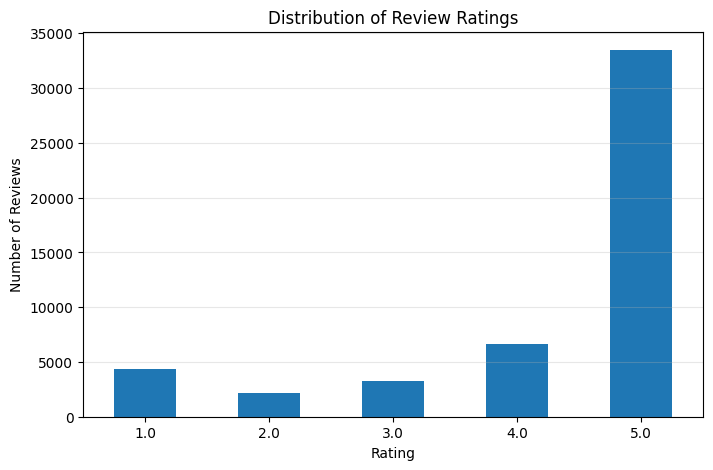

In [12]:
# วัตถุประสงค์: ดูว่าในตัวอย่าง 50,000 reviews ลูกค้าให้คะแนนระดับใดมากที่สุด
# ============================================================
# 5.1 การกระจายของ Rating
# ============================================================

rating_counts = (
    analysis_df["rating"]
    .value_counts()
    .sort_index()
)

print("===== Rating Distribution =====")
print(rating_counts)

# Percentage
rating_percent = (
    analysis_df["rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n===== Rating Percentage =====")
for rating, percent in rating_percent.items():
    print(f"Rating {rating:.0f}: {percent:.2f}%")

# Plot
plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### สรุปผลการวิเคราะห์การกระจายตัวของ Rating

จากการวิเคราะห์การกระจายของ `Rating` พบว่า Rating แต่ละระดับมีจำนวนแตกต่างกัน โดยสามารถเห็นได้ชัดว่าคะแนนระดับ `5.0` มีจำนวน Review มากที่สุด ซึ่งช่วยสะท้อนว่าลูกค้าส่วนมากให้คะแนนสินค้าใน `ระดับดีมาก` จากกลุ่มตัวอย่าง 50,000 reviews

### 5.2 การกระจายของ Reviews ตาม Product

In [13]:
# วัตถุประสงค์: ดูว่าสินค้าแต่ละรายการได้รับ Review มากน้อยแตกต่างกันอย่างไร และหา Product ที่มีจำนวน Reviews สูงสุดใน Sample
# ============================================================
# 5.2 การกระจายของ Reviews ตาม Product
# ============================================================

product_review_counts = (
    analysis_df
    .groupby(["parent_asin", "title"])
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("===== Top 10 Products by Number of Reviews =====")
display(product_review_counts.head(10))

===== Top 10 Products by Number of Reviews =====


,parent_asin,title,review_count
20582,B09857JRP2,GLS Audio Instrument Cable - Amp Cord for Bass...,126
21708,B09W4F2X6S,"BONAOK Wireless Bluetooth Karaoke Microphone, ...",121
24256,B0C6H9T5T6,"Blue Yeti USB Microphone for PC, Mac, Gaming, ...",108
22850,B0BHSG5C3G,"Snark SN5X Clip-On Tuner for Guitar, Bass & Vi...",97
22620,B0BCK6L7S5,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",97
6412,B00DY1F2CS,"Neewer Microphone Arm Stand, Suspension Boom S...",94
23530,B0BSGM6CQ9,Ernie Ball Mondo Slinky Nickelwound Electric G...,87
23614,B0BTR12G3V,Best Choice Products 38in Beginner All Wood Ac...,86
12101,B06ZYJ6SJZ,FIFINE USB Podcast Condenser Microphone Record...,86
19155,B08JMQR2JK,On Stage XCG4 Velveteen Padded Tubular Guitar ...,82


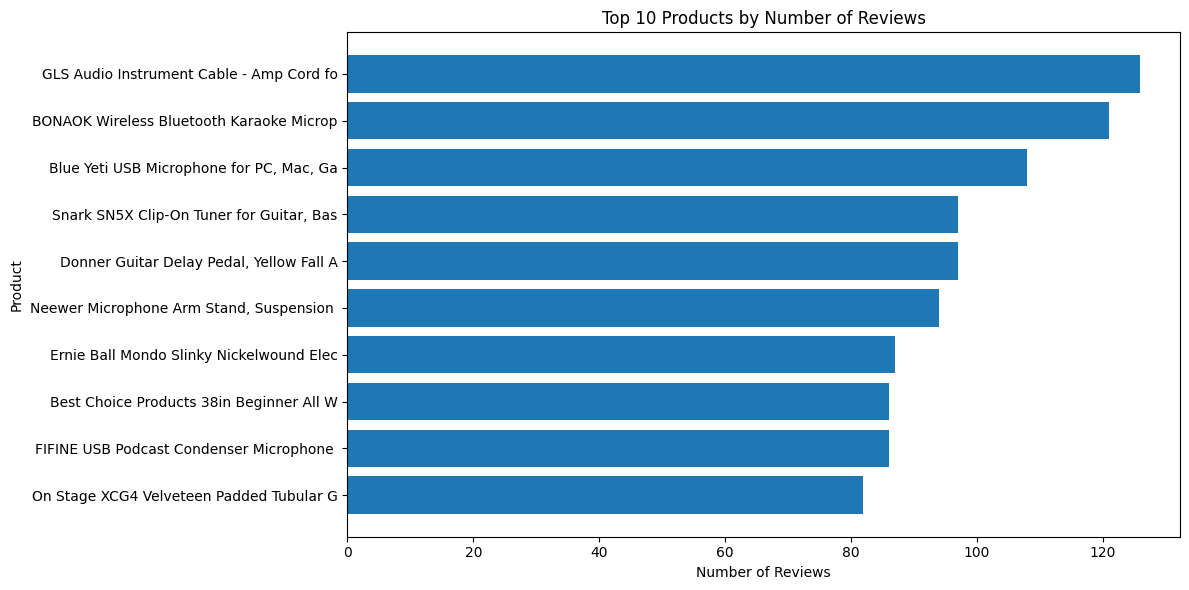

In [14]:
# Top 10 Products
top10_products = product_review_counts.head(10).copy()

# ตัดชื่อสินค้าให้สั้นลงเพื่อให้กราฟอ่านง่าย
top10_products["short_title"] = (
    top10_products["title"]
    .str[:40]
)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_products["short_title"][::-1],
    top10_products["review_count"][::-1]
)

plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [15]:
unique_products = analysis_df["parent_asin"].nunique()

print("Number of unique products:", unique_products)
print("Total reviews:", len(analysis_df))

average_reviews_per_product = (
    len(analysis_df) / unique_products
)

print(
    "Average reviews per product:",
    round(average_reviews_per_product, 2)
)

Number of unique products: 24453
Total reviews: 50000
Average reviews per product: 2.04


###สรุปผลการกระจายของ Reviews ตาม Product
จากการวิเคราะห์ข้อมูล Review จำนวนทั้งหมด 50,000 รายการ พบว่ามีสินค้า `(Unique Products)` จำนวน `24,453 รายการ` โดยมีค่าเฉลี่ยจำนวน Reviews ต่อ Product เท่ากับ `2.04` Reviews ต่อ Product

ผลการวิเคราะห์แสดงให้เห็นว่า แม้ข้อมูลที่นำมาวิเคราะห์จะมีจำนวน Reviews ถึง 50,000 รายการ แต่ Reviews เหล่านี้กระจายอยู่ใน Product จำนวนมาก ทำให้จำนวน `Reviews เฉลี่ยต่อ Product` อยู่ใน `ระดับค่อนข้างต่ำ` ที่ 2.04 Reviews ต่อ Product สะท้อนให้เห็นว่าในกลุ่มตัวอย่างมี Product จำนวนมากที่ได้รับ Reviews เพียงไม่กี่รายการ

ดังนั้น การวิเคราะห์จำนวน Reviews ตาม Product จึงสามารถใช้เพื่อศึกษาว่า Product ใดมีจำนวน Reviews สูงกว่าสินค้าอื่น และช่วยให้เห็นลักษณะการกระจายตัวของ Reviews ภายในกลุ่มตัวอย่างได้ชัดเจนยิ่งขึ้น

### 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา

In [16]:
# ============================================================
# 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา
# ============================================================

analysis_df["review_date"] = pd.to_datetime(
    analysis_df["timestamp"],
    unit="ms"
)

# ตรวจสอบวันที่
print("===== Review Date Range =====")
print("Start:", analysis_df["review_date"].min())
print("End:", analysis_df["review_date"].max())

===== Review Date Range =====
Start: 2001-01-04 15:16:19
End: 2023-09-05 12:24:12.521000


### สรุปผลการวิเคราะห์ Reviews ตามช่วงเวลา
จากการแปลงข้อมูล `timestamp` ให้อยู่ในรูปแบบวันที่ พบว่า Review ในกลุ่มตัวอย่างมีช่วงเวลาตั้งแต่วันที่ 4 มกราคม 2001 เวลา 15:16:19 จนถึงวันที่ 5 กันยายน 2023 เวลา 12:24:12.521

In [17]:
# จำนวน Reviews รายปี

reviews_by_year = (
    analysis_df
    .groupby(analysis_df["review_date"].dt.year)
    .size()
)

print("===== Reviews by Year =====")
print(reviews_by_year)

===== Reviews by Year =====
review_date
2001       1
2002       2
2003       3
2004       8
2005      13
2006      18
2007      48
2008      84
2009      94
2010     276
2011     534
2012     900
2013    1997
2014    2859
2015    4009
2016    4641
2017    4276
2018    4562
2019    5602
2020    6372
2021    6452
2022    5063
2023    2186
dtype: int64


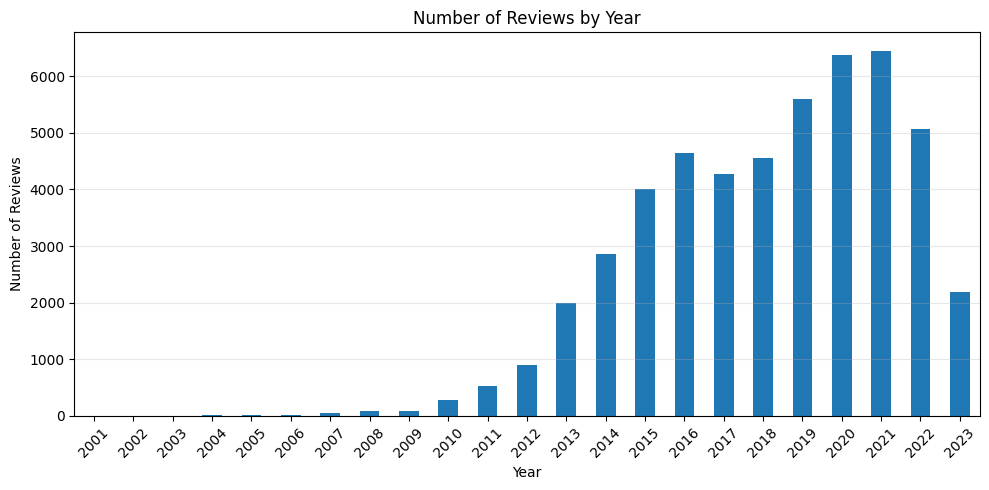

In [18]:
plt.figure(figsize=(10, 5))

reviews_by_year.plot(
    kind="bar"
)

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Reviews รายปี

เมื่อพิจารณาจำนวน `Reviews จำแนกตามปี` พบว่าจำนวน Reviews มี`แนวโน้มเพิ่มขึ้นอย่างต่อเนื่อง`ในช่วงแรกของข้อมูล โดยในปี 2001 มีเพียง 1 Review และเพิ่มขึ้นเป็น 13 Reviews ในปี 2005, 94 Reviews ในปี 2009 และ 276 Reviews ในปี 2010

หลังจากนั้นจำนวน Reviews `เพิ่มขึ้นอย่างชัดเจน` โดยมี 534 Reviews ในปี 2011, 900 Reviews ในปี 2012, 1,997 Reviews ในปี 2013, 2,859 Reviews ในปี 2014 และ 4,009 Reviews ในปี 2015

ในปี 2016 มีจำนวน 4,641 Reviews และปี 2017 มี 4,276 Reviews ขณะที่ปี 2018 มี 4,562 Reviews จากนั้นจำนวน Reviews เพิ่มขึ้นอีกครั้งเป็น 5,602 Reviews ในปี 2019 และ 6,372 Reviews ในปี 2020

ปี `2021 เป็นปีที่มีจำนวน Reviews สูงที่สุด` ในข้อมูลชุดนี้ โดยมีจำนวน 6,452 Reviews หลังจากนั้นจำนวน Reviews ลดลงเป็น 5,063 Reviews ในปี 2022 และเหลือ 2,186 Reviews ในปี 2023 อย่างไรก็ตาม ข้อมูลปี 2023 ครอบคลุมเพียงช่วงวันที่ 1 มกราคมถึง 5 กันยายน จึงไม่ควรนำจำนวน Reviews ของปี 2023 ไปเปรียบเทียบกับปีที่มีข้อมูลครบทั้งปีโดยตรง

โดยสรุป ช่วงปี 2019–2022 เป็นช่วงที่มีจำนวน Reviews ในระดับสูงเมื่อเปรียบเทียบกับช่วงก่อนหน้า และปี 2021 มีจำนวน Reviews สูงสุดในกลุ่มตัวอย่างที่ 6,452 Reviews

In [19]:
reviews_by_month = (
    analysis_df
    .set_index("review_date")
    .resample("M")
    .size()
)

print("===== Monthly Reviews =====")
display(reviews_by_month.head(20))

===== Monthly Reviews =====


/tmp/ipykernel_2708/2015618365.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,0
review_date,
2001-01-31,1
2001-02-28,0
2001-03-31,0
2001-04-30,0
2001-05-31,0
2001-06-30,0
2001-07-31,0
2001-08-31,0
2001-09-30,0


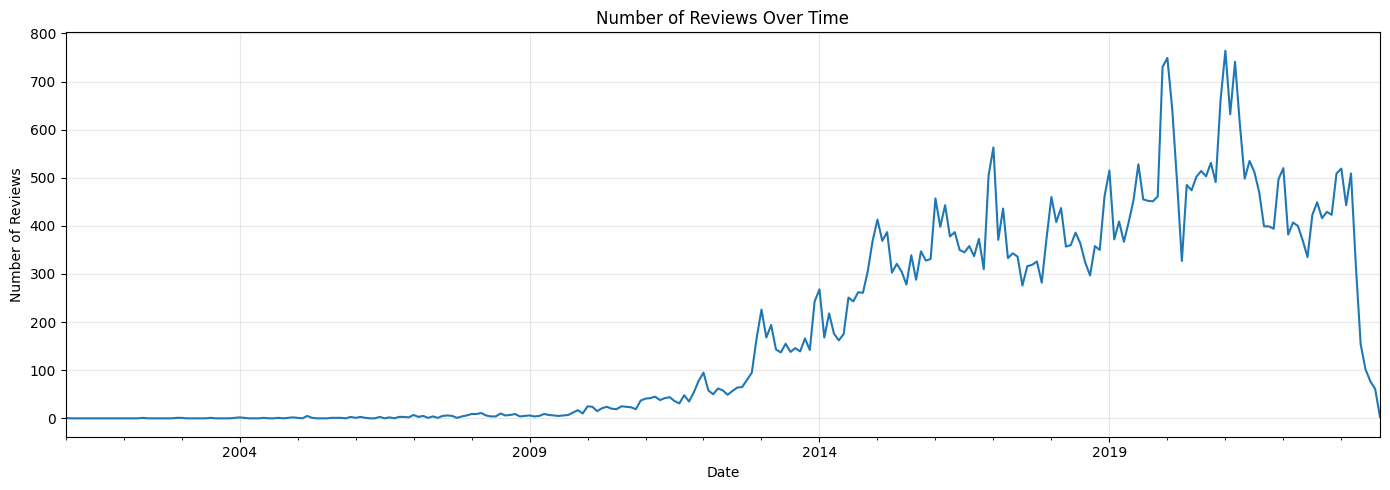

In [20]:
plt.figure(figsize=(14, 5))

reviews_by_month.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2708/3152686850.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["rating"]


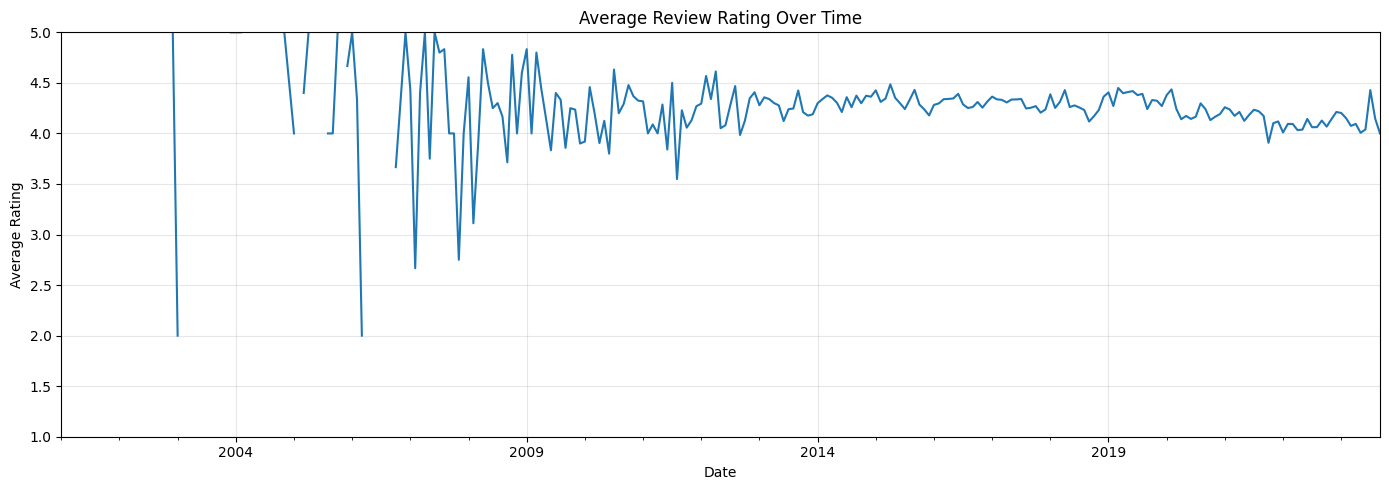

In [21]:
monthly_rating = (
    analysis_df
    .set_index("review_date")
    .resample("M")["rating"]
    .mean()
)

plt.figure(figsize=(14, 5))

monthly_rating.plot()

plt.title("Average Review Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(1, 5)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Review รายเดือน

การวิเคราะห์รายเดือน พบว่า Reviews มีการกระจายอยู่ในหลายช่วงเวลา โดยในช่วงต้นของ Dataset มี`บางเดือนที่ไม่มี Reviews` และ`บางเดือนมี Reviews เพียงเล็กน้อย` ซึ่งสอดคล้องกับจำนวน Reviews รายปีที่มีจำนวนน้อยในช่วงปีแรก ๆ ของข้อมูล

### 5.4 การเปรียบเทียบ Review Rating กับ Product Average Rating

In [22]:
# ============================================================
# 5.4 Review Rating vs Product Average Rating
# ============================================================

comparison = analysis_df[
    ["rating", "average_rating"]
].dropna()

print("===== Rating Comparison =====")
display(
    comparison.describe()
)

===== Rating Comparison =====


,rating,average_rating
count,50000.000000,50000.000000
mean,4.252340,4.373490
std,1.279663,0.412278
min,1.000000,1.000000
25%,4.000000,4.200000
50%,5.000000,4.500000
75%,5.000000,4.600000
max,5.000000,5.000000


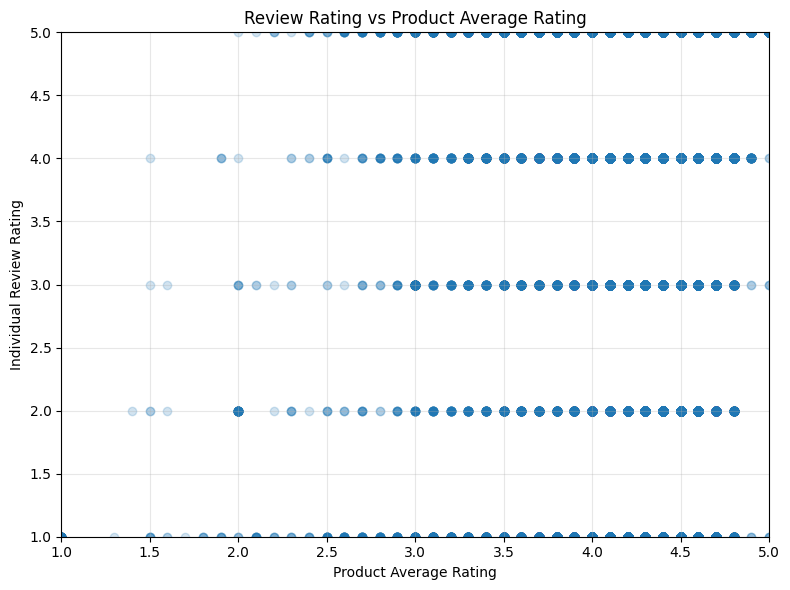

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["average_rating"],
    comparison["rating"],
    alpha=0.2
)

plt.title(
    "Review Rating vs Product Average Rating"
)

plt.xlabel("Product Average Rating")
plt.ylabel("Individual Review Rating")

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
print("===== Mean Comparison =====")

print(
    "Mean Individual Review Rating:",
    round(comparison["rating"].mean(), 3)
)

print(
    "Mean Product Average Rating:",
    round(comparison["average_rating"].mean(), 3)
)

===== Mean Comparison =====
Mean Individual Review Rating: 4.252
Mean Product Average Rating: 4.373


In [25]:
comparison = comparison.copy()

comparison["rating_difference"] = (
    comparison["rating"]
    - comparison["average_rating"]
)

print("===== Rating Difference =====")

display(
    comparison["rating_difference"].describe()
)

===== Rating Difference =====


,rating_difference
count,50000.000000
mean,-0.121150
std,1.224492
min,-4.000000
25%,-0.500000
50%,0.300000
75%,0.600000
max,3.000000


### ผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์พบว่า `Individual Review Rating` มีค่าเฉลี่ยเท่ากับ `4.252` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `1.280`โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

ในขณะที่ `Product Average Rating` มีค่าเฉลี่ยเท่ากับ `4.373` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `0.412` โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

เมื่อเปรียบเทียบค่าเฉลี่ย พบว่า Product Average Rating มี`ค่าเฉลี่ยสูงกว่า` Individual Review Rating โดยมีค่าแตกต่างกันประมาณ 0.121 คะแนน

กล่าวคือ ค่าเฉลี่ยของคะแนน Review รายบุคคลอยู่ที่ 4.252 ในขณะที่ค่าเฉลี่ยของ Product Rating อยู่ที่ 4.373

In [26]:
comparison["comparison_group"] = np.where(
    comparison["rating_difference"] > 0,
    "Review > Product Average",
    np.where(
        comparison["rating_difference"] < 0,
        "Review < Product Average",
        "Review = Product Average"
    )
)

comparison_counts = (
    comparison["comparison_group"]
    .value_counts()
)

print("===== Comparison Groups =====")
print(comparison_counts)

===== Comparison Groups =====
comparison_group
Review > Product Average    33324
Review < Product Average    15094
Review = Product Average     1582
Name: count, dtype: int64


### แบ่งข้อมูล 3 กลุ่ม

เมื่อสร้างตัวแปร rating_difference จากสูตร

`Rating Difference` = `Individual Review Rating − Product Average Rating`

พบว่าค่าเฉลี่ยของความแตกต่างเท่ากับ -0.121 ซึ่งสอดคล้องกับผลการเปรียบเทียบค่าเฉลี่ยข้างต้น นอกจากนี้ ค่าต่ำสุดของความแตกต่างเท่ากับ -4.00 และค่าสูงสุดเท่ากับ 3.00 โดยค่ามัธยฐานอยู่ที่ 0.30

เมื่อแบ่งข้อมูลออกเป็น 3 กลุ่มตามความแตกต่างระหว่าง Review Rating กับ Product Average Rating พบว่า

`Review > Product Average จำนวน 33,324 Reviews`

`Review < Product Average จำนวน 15,094 Reviews`

`Review = Product Average จำนวน 1,582 Reviews`

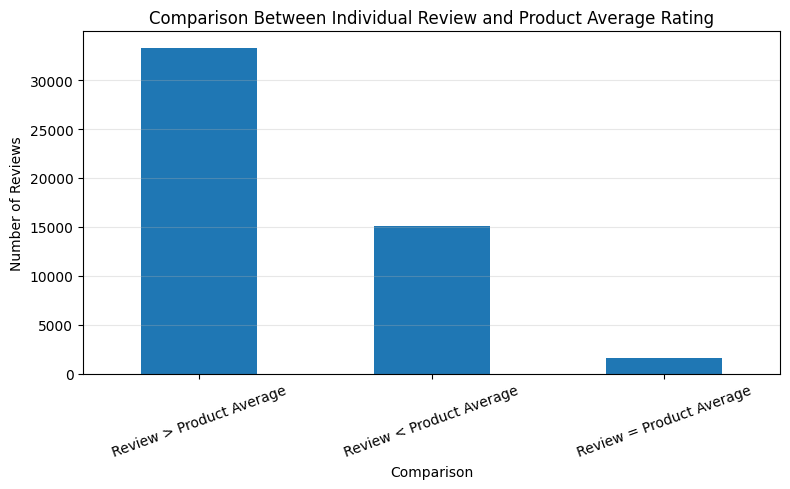

In [27]:
plt.figure(figsize=(8, 5))

comparison_counts.plot(
    kind="bar"
)

plt.title(
    "Comparison Between Individual Review and Product Average Rating"
)

plt.xlabel("Comparison")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### สรุปผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์ส่วนนี้แสดงให้เห็นว่า แม้ค่าเฉลี่ยของ Individual Review Rating จะต่ำกว่าค่าเฉลี่ยของ Product Average Rating แต่เมื่อพิจารณาเป็นราย Review กลับพบว่า Reviews จำนวนมากมีคะแนนสูงกว่า Product Average Rating ของสินค้านั้น ๆ ทั้งนี้ ค่า Product Average Rating เป็นค่าที่สรุปในระดับ Product ขณะที่ Individual Review Rating เป็นคะแนนของ Review แต่ละรายการ จึงควรพิจารณาความแตกต่างของระดับข้อมูลดังกล่าวประกอบการตีความผล

### 5.5 สรุปผลการทำ EDA

###ด้าน Product:

พบสินค้าไม่ซ้ำกันทั้งหมด **24,453 รายการ** จาก Reviews จำนวน **50,000 records** หรือเฉลี่ยประมาณ **2.04 Reviews ต่อ Product** แสดงว่า Sample มี Reviews กระจายอยู่ใน Product จำนวนมาก และไม่ได้กระจุกตัวอยู่กับ Product เพียงไม่กี่รายการ


###ด้านช่วงเวลา:
ข้อมูล Reviews ครอบคลุมตั้งแต่ ปี 2001–2023 โดยจำนวน Reviews `เพิ่มขึ้น`อย่างชัดเจนในช่วงหลัง และ`สูงสุดในปี 2021` จำนวน 6,452 Reviews



###ด้าน Rating:

คะแนน Review Rating เฉลี่ยอยู่ที่ **4.252** ขณะที่ Product Average Rating เฉลี่ยอยู่ที่ **4.373** โดยเมื่อเปรียบเทียบคะแนน Review กับ Product Average Rating พบว่า **33,324 Reviews** มีคะแนนสูงกว่า Product Average Rating, **15,094 Reviews** มีคะแนนต่ำกว่า และ **1,582 Reviews** มีคะแนนเท่ากัน

ผลดังกล่าวใช้เป็นข้อมูลพื้นฐานสำหรับขั้นตอนถัดไปในการวิเคราะห์ว่า Text Features ของ Product เช่น ความยาวของ Title และจำนวน Feature Bullets มีรูปแบบความสัมพันธ์กับ Rating แตกต่างกันอย่างไร


###สรุปภาพรวม:
EDA แสดงให้เห็นลักษณะการกระจายของ Reviews ตาม Product, ช่วงเวลา และ Rating ซึ่งช่วยให้เข้าใจโครงสร้างและแนวโน้มของข้อมูลก่อนนำไปวิเคราะห์ในขั้นตอนถัดไป

## 6. Text Features (เวฟ)

## เลือก Client Brief

**B1 ปรับปรุงสินค้า**

- **ลูกค้าคือทีม:** Product Team
- **เขากำลังจะตัดสินใจเรื่อง:** สินค้ากลุ่มไหนควรได้รับการพิจารณาตรวจสอบและปรับปรุงก่อน โดยพิจารณาจากสัญญาณปัญหาที่สะท้อนผ่าน Customer Rating
- **ถ้าตัดสินใจผิดจะเสียอะไร:** อาจใช้งบประมาณและทรัพยากรในการตรวจสอบหรือปรับปรุงสินค้ากับกลุ่มหรือประเด็นที่มีความสำคัญน้อยกว่า ในขณะที่สินค้าที่มีสัญญาณปัญหามากกว่าอาจไม่ได้รับการตรวจสอบก่อน
- **คำถามที่เราจะตอบให้เขา:** สินค้ากลุ่มใดมีสัญญาณปัญหาจาก Customer Rating มากกว่า และลักษณะของ Product Metadata เช่น ราคา ความยาวของ Title และจำนวน Feature Bullets มีความสัมพันธ์กับ Bad Review อย่างไร เพื่อใช้เป็นข้อมูลประกอบการพิจารณาว่าสินค้ากลุ่มใดควรนำไปตรวจสอบและปรับปรุงก่อน
- **เกณฑ์เบื้องต้น:** กำหนด `rating ≤ 2` เป็น Bad Review และใช้สัดส่วน Bad Review เป็นหนึ่งในตัวชี้วัดสัญญาณปัญหาของสินค้า
- **สมมติฐานตั้งต้นของเรา:** สินค้าหรือกลุ่มสินค้าที่มีสัดส่วน Bad Review สูงอาจมีลักษณะของ Product Metadata ที่แตกต่างจากสินค้าที่มีสัดส่วน Bad Review ต่ำ

### 6.1 ตรวจสอบข้อมูล Text จาก Product Metadata

In [28]:
# Check text-related columns for Text Feature preparation

text_cols = ["title", "features", "description"]

for col in text_cols:
    print(f"\n--- {col} ---")
    print("Missing values:", analysis_df[col].isna().sum())
    print("Non-missing:", analysis_df[col].notna().sum())


--- title ---
Missing values: 0
Non-missing: 50000

--- features ---
Missing values: 0
Non-missing: 50000

--- description ---
Missing values: 0
Non-missing: 50000


In [29]:
# Check truly empty values in text columns

for col in ["title", "features", "description"]:
    empty_count = analysis_df[col].apply(
        lambda x: x is None or (isinstance(x, str) and x.strip() == "") or x == []
    ).sum()

    print(f"{col}:")
    print(f"  Truly empty: {empty_count}")
    print(f"  Non-empty:   {len(analysis_df) - empty_count}")

title:
  Truly empty: 7
  Non-empty:   49993
features:
  Truly empty: 3112
  Non-empty:   46888
description:
  Truly empty: 17561
  Non-empty:   32439


In [30]:
# Inspect the structure of the features column

print("Data type of features:")
print(type(analysis_df["features"].iloc[0]))

print("\nExample 1:")
print(analysis_df["features"].iloc[0])

print("\nExample 2:")
print(analysis_df["features"].iloc[1])

print("\nExample 3:")
print(analysis_df["features"].iloc[2])

Data type of features:
<class 'list'>

Example 1:
['CAMO colored tuner!', 'Fully Chromatic Tuner - enabling it to tune any instrument', 'Clip on tune - Rotates 360 degrees for easy viewing', 'Compact, good-looking, very durable and easy to use', 'High brightness LED displays string number and pitch difference, can be used in dark places and stages']

Example 2:
['Preamp/Overdrive/Disttion Pedal f Electric Guitar']

Example 3:
["MINI GUITAR FOR LEARNING: This beginner's acoustic guitar teaches children the basics of music, helping them learn tone, rhythm, and hand-eye coordination to play notes and songs.", 'AUTHENTIC STRINGS: 6 realistic stainless steel guitar strings that look and feel just like the real thing! - not simple wire or nylon like most other toy guitars.', 'REAL GUITAR SOUNDS: This fun guitar for kids features adjustable, working strings that produce authentic musical notes, motivating your little ones to keep practicing their craft.', 'KID-SIZED: Measuring 23" tall x 8" w

In [31]:
# Check current columns in analysis_df

print("Number of columns:", len(analysis_df.columns))
print("\nAll columns:")
print(analysis_df.columns.tolist())

Number of columns: 12

All columns:
['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date']


#### ตรวจสอบข้อมูล Text จาก Product Metadata

ตรวจสอบความพร้อมของข้อมูล `title`, `features` และ `description` จาก **Product Metadata** ก่อนสร้าง Text Features เพื่อใช้ในการวิเคราะห์ความสัมพันธ์ระหว่างลักษณะของ Product กับ Customer Rating และ Bad Review

เนื่องจากข้อมูลว่างอาจอยู่ในรูปแบบ `None`, `NaN`, empty string (`""`) หรือ empty list (`[]`) จึงตรวจสอบทั้ง Missing Values และข้อมูลที่ว่างจริงเพิ่มเติม

ผลการตรวจสอบพบว่า:

- `title` มีข้อมูลว่างจริง **7 records (0.01%)**
- `features` มีข้อมูลว่างจริง **3,112 records (6.22%)**
- `description` มีข้อมูลว่างจริง **17,561 records (35.12%)**

นอกจากนี้ `features` มีโครงสร้างเป็น **list ของข้อความแต่ละรายการ** จึงสามารถนำจำนวนรายการใน list มาใช้สร้าง Text Feature เพื่อสะท้อนจำนวน Feature Bullets ของสินค้าได้

จากผลการตรวจสอบ จึงเลือกใช้ `title` และ `features` เป็นข้อมูลหลักในการสร้าง Text Features เนื่องจากมีข้อมูลพร้อมใช้งานมากกว่า `description` และสามารถนำไปวิเคราะห์ร่วมกับ Rating และเกณฑ์ Bad Review ที่กำหนดในขั้นตอนถัดไปได้

### 6.2 สร้าง Text Feature ที่ 1: `title_word_count`

สร้าง `title_word_count` เพื่อวัดจำนวนคำในชื่อสินค้าจาก `title` โดยใช้จำนวนคำเป็นตัวแทนของความยาวของชื่อสินค้า

จากข้อมูลตัวอย่าง 50,000 records พบว่า Q1 = 8 คำ, Median = 14 คำ และ Q3 = 23 คำ จึงแบ่งความยาวของ Title ตาม quartile เป็น 4 กลุ่ม ได้แก่ Short (≤8), Medium (9–14), Long (15–23) และ Very Long (24+) เพื่อใช้เปรียบเทียบลักษณะของสินค้าแต่ละกลุ่มกับ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ในขั้นตอนการวิเคราะห์ถัดไป

===== title_word_count ====


,title_word_count
count,50000.000000
mean,15.728240
std,8.450677
min,0.000000
25%,8.000000
50%,14.000000
75%,23.000000
max,83.000000



===== จำนวน Records ตามกลุ่มความยาว Title ====
title_length_group
Short (≤8)         13047
Medium (9-14)      12539
Long (15-23)       12626
Very Long (24+)    11788
Name: count, dtype: int64


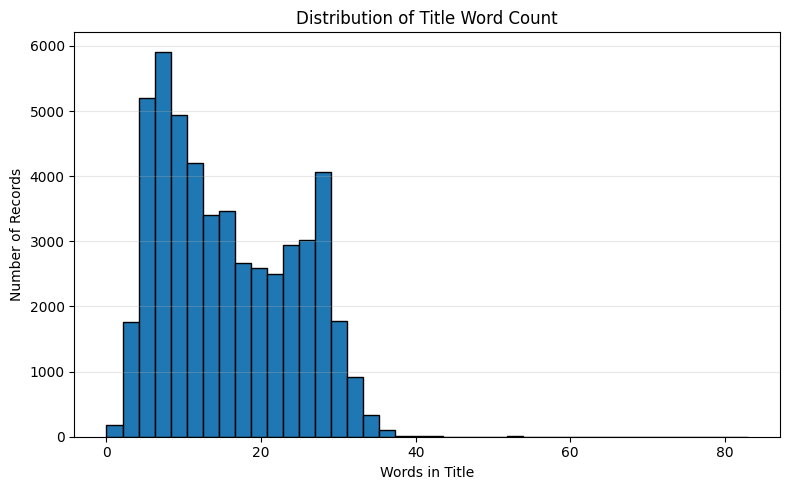

In [32]:
# ============================================================
# 6.2 Text Feature 1: title_word_count
# ============================================================

# นับจำนวนคำในชื่อสินค้า
analysis_df["title_word_count"] = (
    analysis_df["title"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print("===== title_word_count ====")
display(analysis_df["title_word_count"].describe())

# แบ่งกลุ่มความยาว Title ตาม quartile
analysis_df["title_length_group"] = pd.cut(
    analysis_df["title_word_count"],
    bins=[-1, 8, 14, 23, np.inf],
    labels=[
        "Short (≤8)",
        "Medium (9-14)",
        "Long (15-23)",
        "Very Long (24+)"
    ]
)

print("\n===== จำนวน Records ตามกลุ่มความยาว Title ====")
print(analysis_df["title_length_group"].value_counts().sort_index())

# แสดงการกระจายของจำนวนคำใน Title
plt.figure(figsize=(8, 5))
analysis_df["title_word_count"].plot(
    kind="hist",
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Title Word Count")
plt.xlabel("Words in Title")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation of Results

จากผลการวิเคราะห์ `title_word_count` ของข้อมูลจำนวน 50,000 records พบว่า ชื่อสินค้ามีจำนวนคำเฉลี่ย **15.73 คำ** และมีค่ามัธยฐานอยู่ที่ **14 คำ** โดย Q1 อยู่ที่ 8 คำ และ Q3 อยู่ที่ 23 คำ

เมื่อแบ่งข้อมูลตาม quartile พบว่า

- **Short (≤8 คำ)** มี 13,047 records
- **Medium (9–14 คำ)** มี 12,539 records
- **Long (15–23 คำ)** มี 12,626 records
- **Very Long (24+ คำ)** มี 11,788 records

จำนวน records ในแต่ละกลุ่มค่อนข้างใกล้เคียงกัน เนื่องจากจุดแบ่งถูกกำหนดจาก Q1, Median และ Q3 ของข้อมูล

ดังนั้น `title_word_count` สามารถใช้เป็น Text Feature สำหรับเปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review ระหว่างกลุ่มความยาวของ Title ในขั้นตอนถัดไปได้ อย่างไรก็ตาม ผลลัพธ์ในขั้นตอนนี้แสดงเพียงการกระจายของความยาว Title และยังไม่สามารถสรุปได้ว่าความยาวของชื่อสินค้ามีความสัมพันธ์กับ Rating หรือ Bad Review จนกว่าจะทำการวิเคราะห์เปรียบเทียบเพิ่มเติม

### 6.3 สร้าง Text Feature ที่ 2: `feature_bullet_count`

สร้าง `feature_bullet_count` เพื่อวัดจำนวน Feature Bullets ที่ระบุไว้ใน Product Metadata ของสินค้า โดยใช้จำนวน bullet เป็นตัวแทนของปริมาณรายละเอียดที่ผู้ขายนำเสนอในส่วน Features

เนื่องจาก `features` มีลักษณะเป็น list ของข้อความ จึงนับจำนวนสมาชิกใน list ของแต่ละสินค้า

จากนั้นแบ่งสินค้าออกเป็น 4 กลุ่ม ได้แก่ 0 bullets, 1–3 bullets, 4–5 bullets และ 6+ bullets เพื่อใช้เปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ระหว่างกลุ่มในขั้นตอนการวิเคราะห์ต่อไป

===== feature_bullet_count ====


,feature_bullet_count
count,50000.000000
mean,4.481080
std,1.655952
min,0.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,33.000000



===== จำนวน Records ตามจำนวน Feature Bullets ====
feature_bullet_group
0 bullets       3112
1-3 bullets     4938
4-5 bullets    37770
6+ bullets      4180
Name: count, dtype: int64


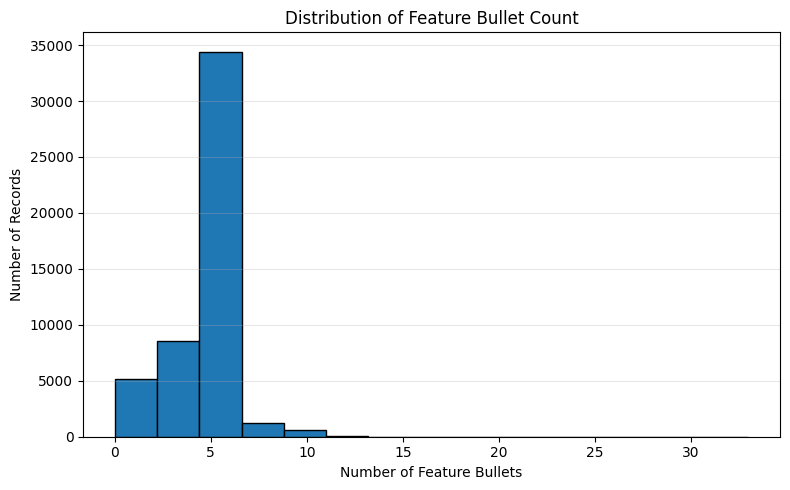

In [33]:
# ============================================================
# 6.3 Text Feature 2: feature_bullet_count
# ============================================================

# นับจำนวน Feature Bullets ของแต่ละสินค้า
analysis_df["feature_bullet_count"] = analysis_df["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("===== feature_bullet_count ====")
display(analysis_df["feature_bullet_count"].describe())

# แบ่งกลุ่มตามจำนวน Feature Bullets
analysis_df["feature_bullet_group"] = pd.cut(
    analysis_df["feature_bullet_count"],
    bins=[-1, 0, 3, 5, np.inf],
    labels=[
        "0 bullets",
        "1-3 bullets",
        "4-5 bullets",
        "6+ bullets"
    ]
)

print("\n===== จำนวน Records ตามจำนวน Feature Bullets ====")
print(analysis_df["feature_bullet_group"].value_counts().sort_index())

# แสดงการกระจายของจำนวน Feature Bullets
plt.figure(figsize=(8, 5))

analysis_df["feature_bullet_count"].plot(
    kind="hist",
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Feature Bullet Count")
plt.xlabel("Number of Feature Bullets")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretation of Results

จากการวิเคราะห์ `feature_bullet_count` ของข้อมูลจำนวน 50,000 records พบว่า สินค้ามีจำนวน Feature Bullets เฉลี่ย **4.48 bullets** และมีค่ามัธยฐาน **5 bullets** โดยมีค่า Q1 = **4 bullets** และ Q3 = **5 bullets**

เมื่อพิจารณาจาก Histogram พบว่าจำนวน Feature Bullets ส่วนใหญ่อยู่ในช่วงประมาณ **4–5 bullets** ขณะที่บางสินค้ามีจำนวน bullets สูงกว่านั้น โดยค่าต่ำสุดอยู่ที่ **0 bullets** และค่าสูงสุดอยู่ที่ **33 bullets**

เมื่อแบ่งข้อมูลตามจำนวน Feature Bullets พบว่า

- **0 bullets:** 3,112 records
- **1–3 bullets:** 4,938 records
- **4–5 bullets:** 37,770 records
- **6+ bullets:** 4,180 records

กลุ่ม **4–5 bullets มีจำนวนมากที่สุด** คิดเป็นประมาณ **75.54%** ของข้อมูลทั้งหมด ขณะที่กลุ่มที่ไม่มี Feature Bullets มี 3,112 records หรือประมาณ **6.22%**

ดังนั้น `feature_bullet_count` สามารถใช้เป็น Text Feature เพื่อสะท้อนปริมาณรายละเอียดที่แสดงในส่วน Features ของสินค้า และนำไปเปรียบเทียบความแตกต่างของ `rating` และสัดส่วน Bad Review (`rating ≤ 2`) ระหว่างกลุ่มได้ในขั้นตอนถัดไป

อย่างไรก็ตาม ผลลัพธ์ในขั้นตอนนี้แสดงเพียงจำนวนและการกระจายของ Feature Bullets ยังไม่สามารถสรุปได้ว่าจำนวน Feature Bullets มีความสัมพันธ์กับ Rating หรือ Bad Review ในลักษณะใด จนกว่าจะทำการวิเคราะห์เปรียบเทียบเพิ่มเติม

### 6.4 วิเคราะห์ Text Features กับ Rating และ Bad Review

หลังจากสร้าง Text Features จาก Product Metadata ได้แก่ `title_word_count` และ `feature_bullet_count` แล้ว ขั้นตอนนี้จะนำ Text Features ดังกล่าวมาเปรียบเทียบกับ Customer Rating เพื่อศึกษาว่าลักษณะของข้อมูลสินค้าแต่ละแบบมีรูปแบบของ Rating และ Bad Review แตกต่างกันหรือไม่

ในการวิเคราะห์นี้กำหนด **Bad Review = `rating ≤ 2`** ตามเกณฑ์ที่กำหนดไว้ใน Client Brief เพื่อใช้เป็นสัญญาณเบื้องต้นของปัญหาที่อาจต้องนำสินค้าไปตรวจสอบเพิ่มเติม

การวิเคราะห์จะแบ่งเป็น 2 ส่วน ได้แก่

1. เปรียบเทียบกลุ่มความยาวของ Title และจำนวน Feature Bullets กับค่าเฉลี่ย Review Rating และสัดส่วน Bad Review
2. คำนวณ Spearman Correlation ระหว่าง Text Features กับ `rating` และ `average_rating` เพื่อดูทิศทางและขนาดของความสัมพันธ์

ผลการวิเคราะห์นี้ใช้เป็นหลักฐานประกอบ Client Brief **B1 ปรับปรุงสินค้า | Product** โดยมุ่งดูว่า Text Features ของสินค้าแต่ละกลุ่มมีรูปแบบของ Bad Review แตกต่างกันหรือไม่ เพื่อใช้เป็นข้อมูลประกอบการพิจารณาว่าสินค้าหรือกลุ่มสินค้าใดควรถูกนำไปตรวจสอบเพิ่มเติม

ทั้งนี้ การวิเคราะห์เป็นการวิเคราะห์เชิงพรรณนาและความสัมพันธ์ จึงไม่สามารถสรุปได้ว่า Text Features เป็นสาเหตุที่ทำให้ Rating สูงหรือต่ำ หรือเป็นสาเหตุโดยตรงของ Bad Review

In [34]:
print("===== Columns in analysis_df ====")
print(analysis_df.columns.tolist())

===== Columns in analysis_df ====
['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date', 'title_word_count', 'title_length_group', 'feature_bullet_count', 'feature_bullet_group']


===== Title Length vs Rating & Bad Review =====


,reviews,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
title_length_group,,,,,
Short (≤8),13047,4.308,4.361,1495,11.459
Medium (9-14),12539,4.290,4.377,1528,12.186
Long (15-23),12626,4.201,4.371,1819,14.407
Very Long (24+),11788,4.205,4.387,1740,14.761



===== Feature Bullets vs Rating & Bad Review =====


,reviews,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
feature_bullet_group,,,,,
0 bullets,3112,4.091,4.154,522,16.774
1-3 bullets,4938,4.288,4.333,591,11.968
4-5 bullets,37770,4.261,4.390,4916,13.016
6+ bullets,4180,4.252,4.436,553,13.230


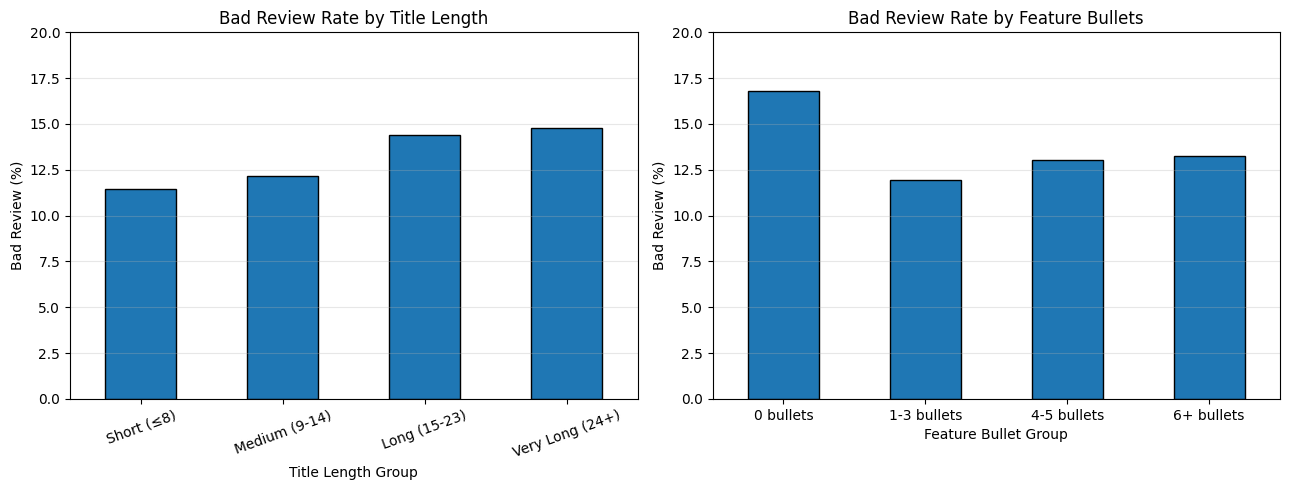

In [40]:
from scipy.stats import spearmanr

def group_summary(group_col):
    return (
        analysis_df.groupby(group_col, observed=True)
        .agg(
            reviews=("rating", "size"),
            mean_review_rating=("rating", "mean"),
            mean_product_rating=("average_rating", "mean"),
            bad_reviews=("rating", lambda s: (s <= 2).sum()),
            bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100),
        )
        .round(3)
    )

print("===== Title Length vs Rating & Bad Review =====")
title_summary = group_summary("title_length_group")
display(title_summary)

print("\n===== Feature Bullets vs Rating & Bad Review =====")
feature_summary = group_summary("feature_bullet_group")
display(feature_summary)

# ===== Visualization: Text Features vs Bad Review =====

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Title Length vs Bad Review
title_summary["bad_review_pct"].plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black"
)

axes[0].set_title("Bad Review Rate by Title Length")
axes[0].set_xlabel("Title Length Group")
axes[0].set_ylabel("Bad Review (%)")
axes[0].set_ylim(0, 20)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)


# 2. Feature Bullets vs Bad Review
feature_summary["bad_review_pct"].plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black"
)

axes[1].set_title("Bad Review Rate by Feature Bullets")
axes[1].set_xlabel("Feature Bullet Group")
axes[1].set_ylabel("Bad Review (%)")
axes[1].set_ylim(0, 20)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# ===== Spearman Correlation =====

corr_rows = []

for feat in ["title_word_count", "feature_bullet_count"]:
    for target in ["rating", "average_rating"]:
        tmp = analysis_df[[feat, target]].dropna()

        rho, p = spearmanr(tmp[feat], tmp[target])

        corr_rows.append({
            "Text Feature": feat,
            "Rating": target,
            "Spearman rho": round(rho, 4),
            "p-value": p
        })

print("===== Spearman Correlation =====")
display(pd.DataFrame(corr_rows))

===== Spearman Correlation =====


,Text Feature,Rating,Spearman rho,p-value
0,title_word_count,rating,-0.0256,9.707971e-09
1,title_word_count,average_rating,-0.0286,1.506742e-10
2,feature_bullet_count,rating,0.0059,1.887239e-01
3,feature_bullet_count,average_rating,0.0670,7.355430e-51


#### Interpretation of Results

จากการเปรียบเทียบ Text Features กับ Customer Rating และ Bad Review ในข้อมูลตัวอย่าง 50,000 records พบรูปแบบที่แตกต่างกันระหว่างความยาวของ Title และจำนวน Feature Bullets

**1. Title Length กับ Rating และ Bad Review**

กลุ่ม Short (≤8 คำ) มีค่าเฉลี่ย Review Rating เท่ากับ **4.308** และมีสัดส่วน Bad Review (`rating ≤ 2`) เท่ากับ **11.459%** ขณะที่กลุ่ม Very Long (24+ คำ) มีค่าเฉลี่ย Review Rating เท่ากับ **4.205** และมีสัดส่วน Bad Review เท่ากับ **14.761%**

เมื่อเปรียบเทียบ Short กับ Very Long พบว่า Mean Review Rating ต่ำลง **0.103 คะแนน** และสัดส่วน Bad Review สูงขึ้น **3.302 percentage points**

อย่างไรก็ตาม Spearman correlation ระหว่าง `title_word_count` กับ `rating` มีค่า **-0.0256** ซึ่งใกล้ศูนย์ แสดงว่าความสัมพันธ์โดยรวมมีขนาดเล็กมาก แม้ p-value จะมีค่าต่ำกว่า 0.001 เช่นเดียวกับความสัมพันธ์ระหว่าง `title_word_count` กับ `average_rating` ที่มีค่า rho เท่ากับ **-0.0286**

ดังนั้น ผลดังกล่าวสะท้อนว่าในข้อมูลตัวอย่างนี้ Title ที่ยาวมากมีรูปแบบของ Rating และ Bad Review แตกต่างจาก Title ที่สั้นกว่า แต่ขนาดความสัมพันธ์โดยรวมระหว่างจำนวนคำใน Title กับ Rating มีค่อนข้างน้อย

**2. Feature Bullets กับ Rating และ Bad Review**

กลุ่มที่ไม่มี Feature Bullets มีค่าเฉลี่ย Review Rating ต่ำที่สุดที่ **4.091** และมีสัดส่วน Bad Review สูงที่สุดที่ **16.774%** ขณะที่กลุ่ม 1–3 bullets มีค่าเฉลี่ย Review Rating **4.288** และ Bad Review **11.968%**

อย่างไรก็ตาม Spearman correlation ระหว่าง `feature_bullet_count` กับ `rating` เท่ากับ **0.0059** และมี p-value เท่ากับ **0.1887** จึงยังไม่มีหลักฐานเพียงพอที่จะสรุปว่าจำนวน Feature Bullets มีความสัมพันธ์กับ Review Rating โดยตรง

สำหรับ `average_rating` พบ Spearman correlation เท่ากับ **0.0670** ซึ่งเป็นความสัมพันธ์ทางบวกที่มีขนาดเล็กมาก แม้จะมี p-value ต่ำกว่า 0.001 แต่ขนาดของความสัมพันธ์ยังอยู่ในระดับต่ำ

**3. Business Implication สำหรับ B1**

จากผลการวิเคราะห์ พบว่าสินค้าที่มี **Title ยาวมาก** และสินค้าที่ **ไม่มี Feature Bullets** มีสัดส่วน Bad Review สูงกว่าบางกลุ่ม โดยเฉพาะกลุ่ม Very Long Title มี Bad Review **14.761%** และกลุ่ม 0 bullets มี Bad Review **16.774%**

ผลนี้สามารถใช้เป็นสัญญาณเบื้องต้นเพื่อช่วย Product Team ระบุกลุ่มสินค้าที่ควรนำไปตรวจสอบเพิ่มเติม อย่างไรก็ตาม Text Features เพียงอย่างเดียวไม่ควรถูกใช้เป็นเกณฑ์ตัดสินว่าสินค้าใดต้องปรับปรุง เนื่องจาก Spearman correlation โดยรวมมีขนาดเล็ก และผลการวิเคราะห์นี้เป็นเพียงความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่า Title หรือ Feature Bullets เป็นสาเหตุของ Bad Review

### 6.5 วิเคราะห์กลุ่ม Product จาก Text Features

จากผลการวิเคราะห์ในข้อ 6.4 พบว่า Text Features แต่ละตัวมีรูปแบบของ Rating และ Bad Review แตกต่างกัน จึงนำ `title_length_group` และ `feature_bullet_group` มาพิจารณาร่วมกัน เพื่อระบุกลุ่ม Product ที่มีลักษณะของ Product Metadata แตกต่างกัน และเปรียบเทียบค่าเฉลี่ย Review Rating รวมถึงสัดส่วน Bad Review (`rating ≤ 2`) ของแต่ละกลุ่ม

การวิเคราะห์นี้ช่วยให้เห็นว่ากลุ่ม Product ที่มีลักษณะของ Title และ Feature Bullets แบบใดมีสัดส่วน Bad Review สูงกว่า และสามารถใช้เป็นหลักฐานประกอบการระบุประเด็นของ Product Metadata ที่ควรนำไปตรวจสอบเพิ่มเติมในมุมมองของ Product Team

ทั้งนี้ การแบ่งกลุ่มดังกล่าวเป็นการแบ่งตามลักษณะของ Product Metadata ไม่ใช่หมวดหมู่สินค้า และผลลัพธ์เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปความเป็นเหตุและผลได้

In [36]:
print(analysis_df.columns.tolist())

['user_id', 'parent_asin', 'rating', 'timestamp', 'title', 'features', 'description', 'average_rating', 'rating_number', 'price', 'store', 'review_date', 'title_word_count', 'title_length_group', 'feature_bullet_count', 'feature_bullet_group']


In [42]:
# ===== 6.5 Product Group by Title Length and Feature Bullets =====

product_text_group_summary = (
    analysis_df
    .groupby(
        ["title_length_group", "feature_bullet_group"],
        observed=True
    )
    .agg(
        records=("rating", "size"),
        products=("parent_asin", "nunique"),
        mean_review_rating=("rating", "mean"),
        mean_product_rating=("average_rating", "mean"),
        bad_reviews=("rating", lambda s: (s <= 2).sum()),
        bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100)
    )
    .reset_index()
)

product_text_group_summary = product_text_group_summary.round(3)

print("===== Product Group by Title Length and Feature Bullets =====")
display(product_text_group_summary)

===== Product Group by Title Length and Feature Bullets =====


,title_length_group,feature_bullet_group,records,products,mean_review_rating,mean_product_rating,bad_reviews,bad_review_pct
0,Short (≤8),0 bullets,598,484,4.254,4.196,71,11.873
1,Short (≤8),1-3 bullets,2570,1672,4.284,4.317,301,11.712
2,Short (≤8),4-5 bullets,8746,4665,4.323,4.377,981,11.217
3,Short (≤8),6+ bullets,1133,436,4.282,4.417,142,12.533
4,Medium (9-14),0 bullets,945,750,4.116,4.137,147,15.556
5,Medium (9-14),1-3 bullets,1752,1069,4.322,4.344,200,11.416
6,Medium (9-14),4-5 bullets,8915,4568,4.296,4.404,1083,12.148
7,Medium (9-14),6+ bullets,927,410,4.348,4.423,98,10.572
8,Long (15-23),0 bullets,898,687,4.029,4.132,164,18.263
9,Long (15-23),1-3 bullets,512,257,4.199,4.395,76,14.844


#### Interpretation of Results

เมื่อพิจารณา `title_length_group` และ `feature_bullet_group` ร่วมกัน พบว่าบางกลุ่มมีค่าเฉลี่ย Review Rating และสัดส่วน Bad Review แตกต่างจากกลุ่มอื่นในข้อมูลตัวอย่าง โดยกลุ่มที่มี Title ยาวและไม่มี Feature Bullets มีสัดส่วน Bad Review ค่อนข้างสูง

กลุ่ม **Very Long (24+) + 0 bullets** มีจำนวน **671 records จาก 503 products** โดยมีค่าเฉลี่ย Review Rating เท่ากับ **3.991** และมีสัดส่วน Bad Review (`rating ≤ 2`) เท่ากับ **20.864%**

เมื่อเปรียบเทียบกับกลุ่ม **Very Long (24+) + 4–5 bullets** ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และสัดส่วน Bad Review **14.277%** พบว่ากลุ่ม Very Long + 0 bullets มีค่าเฉลี่ย Rating ต่ำกว่าประมาณ **0.230 คะแนน** และมีสัดส่วน Bad Review สูงกว่าประมาณ **6.587 percentage points**

ในทิศทางเดียวกัน กลุ่ม **Long (15–23) + 0 bullets** มีค่าเฉลี่ย Review Rating **4.029** และสัดส่วน Bad Review **18.263%** ขณะที่กลุ่ม **Long + 4–5 bullets** มีค่าเฉลี่ย Review Rating **4.216** และสัดส่วน Bad Review **14.092%** ซึ่งแตกต่างกันประมาณ **0.187 คะแนน** และ **4.171 percentage points** ตามลำดับ

ผลลัพธ์นี้จึงสามารถใช้เป็น **สัญญาณเบื้องต้นสำหรับการคัดกรองกลุ่ม Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยเฉพาะกลุ่มที่มี Title ยาวและไม่มี Feature Bullets เพื่อพิจารณาความครบถ้วนและความชัดเจนของข้อมูล Product Metadata

อย่างไรก็ตาม ผลลัพธ์นี้เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่าการไม่มี Feature Bullets หรือการมี Title ที่ยาวเป็นสาเหตุโดยตรงของ Rating ที่ต่ำ เนื่องจากอาจมีปัจจัยอื่นที่เกี่ยวข้องกับ Customer Rating ดังนั้นผลการวิเคราะห์นี้ควรใช้เป็นข้อมูลประกอบการคัดกรองและตรวจสอบเพิ่มเติม ไม่ใช่เกณฑ์ตัดสินว่าสินค้าใดต้องปรับปรุงโดยตรง

### 6.6 สรุปผลการวิเคราะห์ Text Features

จากการวิเคราะห์ Text Features ของ Product Metadata จำนวน **50,000 records** ได้สร้าง Text Features จำนวน 2 ตัว ได้แก่ `title_word_count` ซึ่งใช้วัดจำนวนคำในชื่อสินค้า และ `feature_bullet_count` ซึ่งใช้วัดจำนวน Feature Bullets ของสินค้า

ผลการวิเคราะห์พบว่า `title_word_count` มี Spearman correlation กับ `rating` เท่ากับ **-0.0256** ซึ่งเป็นความสัมพันธ์เชิงลบที่มีขนาดเล็กมาก ขณะที่ `feature_bullet_count` มี Spearman correlation กับ `rating` เท่ากับ **0.0059** ซึ่งใกล้ศูนย์ แสดงว่าในข้อมูลตัวอย่างไม่พบความสัมพันธ์เชิงอันดับที่ชัดเจนระหว่างจำนวน Feature Bullets กับ Review Rating

เมื่อพิจารณา Text Features สองตัวร่วมกัน พบกลุ่มที่มีสัดส่วน Bad Review (`rating ≤ 2`) ค่อนข้างสูง คือ **Very Long Title (24+ คำ) และ 0 Feature Bullets** ซึ่งมีค่าเฉลี่ย Review Rating **3.991** และสัดส่วน Bad Review **20.864%** จาก **671 records และ 503 products**

เมื่อเปรียบเทียบกับกลุ่ม **Very Long Title + 4–5 Feature Bullets** ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และสัดส่วน Bad Review **14.277%** พบว่ากลุ่ม Very Long + 0 bullets มีค่าเฉลี่ย Rating ต่ำกว่าประมาณ **0.230 คะแนน** และมีสัดส่วน Bad Review สูงกว่าประมาณ **6.587 percentage points**

ผลลัพธ์ดังกล่าวสามารถใช้เป็นหลักฐานประกอบ Client Brief **B1 ปรับปรุงสินค้า | Product** โดยใช้เป็น **สัญญาณเบื้องต้นสำหรับคัดกรองกลุ่ม Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยเฉพาะในประเด็นความครบถ้วนและความชัดเจนของข้อมูล Product Metadata

อย่างไรก็ตาม ผลการวิเคราะห์เป็นความสัมพันธ์เชิงพรรณนา ไม่สามารถสรุปได้ว่า Title ที่ยาวหรือการไม่มี Feature Bullets เป็นสาเหตุโดยตรงของ Rating ที่ต่ำ เนื่องจากอาจมีปัจจัยอื่นที่เกี่ยวข้องกับ Customer Rating ดังนั้น ผลลัพธ์นี้ควรใช้เป็นข้อมูลประกอบการคัดกรองและตรวจสอบเพิ่มเติม ก่อนตัดสินใจปรับปรุง Product

### 6.7 วิเคราะห์ระดับ Product ID

จากผลการวิเคราะห์ในข้อ 6.5–6.6 พบว่าบางกลุ่มของ Product Metadata มีสัดส่วน Bad Review สูงกว่ากลุ่มอื่น อย่างไรก็ตาม การวิเคราะห์ในระดับกลุ่มยังไม่สามารถระบุได้ว่า Product ID ใดมีสัญญาณปัญหา

ดังนั้น ขั้นตอนนี้จะเปลี่ยนหน่วยการวิเคราะห์จากระดับกลุ่ม Metadata มาเป็นระดับ `parent_asin` ซึ่งใช้เป็น Product ID โดยสรุปจำนวน Reviews, จำนวน Bad Reviews, สัดส่วน Bad Review และค่าเฉลี่ย Review Rating ของแต่ละ Product

เนื่องจาก Product ที่มีจำนวน Reviews น้อยอาจมีสัดส่วน Bad Review ที่ผันผวนได้ง่าย ขั้นแรกจะตรวจสอบการกระจายของจำนวน Reviews ต่อ Product ก่อน แล้วจึงกำหนดเกณฑ์จำนวน Reviews ขั้นต่ำสำหรับการวิเคราะห์ Product ในขั้นตอนถัดไป

In [43]:
# ===== 6.7 Product-level Rating Summary =====

product_summary = (
    analysis_df
    .groupby("parent_asin")
    .agg(
        reviews=("rating", "size"),
        mean_review_rating=("rating", "mean"),
        bad_reviews=("rating", lambda s: (s <= 2).sum()),
        bad_review_pct=("rating", lambda s: (s <= 2).mean() * 100),
        average_product_rating=("average_rating", "mean"),
        title_length_group=("title_length_group", "first"),
        feature_bullet_group=("feature_bullet_group", "first")
    )
    .reset_index()
)

product_summary = product_summary.round(3)

print("===== Product-level Summary =====")
display(product_summary.head(10))

print("\n===== Number of Products =====")
print("Total products:", len(product_summary))

print("\n===== Reviews per Product =====")
display(product_summary["reviews"].describe())

===== Product-level Summary =====


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
0,0000098906,1,4.0,0,0.0,4.4,Long (15-23),4-5 bullets
1,0312570929,2,3.0,1,50.0,4.2,Short (≤8),6+ bullets
2,0470536454,1,4.0,0,0.0,4.4,Short (≤8),1-3 bullets
3,0634003224,2,5.0,0,0.0,4.7,Medium (9-14),4-5 bullets
4,0689874162,2,3.5,1,50.0,4.6,Short (≤8),1-3 bullets
5,0692218645,1,2.0,1,100.0,3.6,Medium (9-14),1-3 bullets
6,0739005529,1,5.0,0,0.0,4.0,Long (15-23),1-3 bullets
7,0739065912,2,5.0,0,0.0,4.6,Long (15-23),1-3 bullets
8,0739079883,1,4.0,0,0.0,2.8,Short (≤8),4-5 bullets
9,0739079891,2,5.0,0,0.0,4.0,Medium (9-14),4-5 bullets



===== Number of Products =====
Total products: 24453

===== Reviews per Product =====


,reviews
count,24453.000000
mean,2.044739
std,3.902737
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,126.000000


#### Interpretation of Results

จากการวิเคราะห์ในระดับ Product ID โดยใช้ `parent_asin` พบว่าในข้อมูลตัวอย่าง **50,000 records** มี Product ทั้งหมด **24,453 products** โดยแต่ละ Product มีจำนวน Reviews เฉลี่ย **2.045 reviews**

เมื่อพิจารณาการกระจายของจำนวน Reviews ต่อ Product พบว่า Median อยู่ที่ **1 review** และ Q1 เท่ากับ **1 review** ขณะที่ Q3 เท่ากับ **2 reviews** แสดงว่า Product ส่วนใหญ่ใน Sample มีจำนวน Reviews ค่อนข้างน้อย โดยอย่างน้อย 75% ของ Product มี Reviews ไม่เกิน **2 reviews**

ในขณะเดียวกัน จำนวน Reviews ต่อ Product มีค่าสูงสุดถึง **126 reviews** แสดงว่าจำนวน Reviews ระหว่าง Product มีความแตกต่างกันค่อนข้างมาก

ผลดังกล่าวมีความสำคัญต่อการวิเคราะห์ Bad Review เนื่องจาก Product ที่มี Reviews เพียง 1–2 รายการอาจมีสัดส่วน Bad Review สูง เช่น **100% หรือ 50%** ได้จากจำนวน Review ที่น้อย ดังนั้นการใช้ `bad_review_pct` เพียงอย่างเดียวอาจไม่เพียงพอสำหรับการคัดกรอง Product ที่ควรนำไปตรวจสอบ

ดังนั้น ในขั้นตอนถัดไปจึงควรกำหนด **Minimum Review Threshold** เพื่อคัดกรอง Product ที่มีจำนวน Reviews เพียงพอสำหรับการเปรียบเทียบ และลดความผันผวนของสัดส่วน Bad Review ก่อนนำไปวิเคราะห์ Product ที่มีสัญญาณปัญหา

### 6.8 กำหนดเกณฑ์จำนวน Reviews ขั้นต่ำสำหรับการคัดกรอง Product

จากข้อ 6.7 พบว่า Product ส่วนใหญ่มีจำนวน Reviews ค่อนข้างน้อย โดย Median อยู่ที่ 1 Review และ Q3 อยู่ที่ 2 Reviews ดังนั้นการใช้สัดส่วน Bad Review (`bad_review_pct`) โดยไม่คำนึงถึงจำนวน Reviews อาจทำให้ Product ที่มีข้อมูลเพียง 1–2 Reviews มีสัดส่วน Bad Review สูงได้ง่าย

เพื่อให้การคัดกรอง Product มีความน่าเชื่อถือมากขึ้น จึงทดลองกำหนด Minimum Review Threshold หลายระดับ ได้แก่ **1, 2, 3, 5, 10 และ 20 Reviews** แล้วเปรียบเทียบว่าหลังจากใช้แต่ละเกณฑ์จะเหลือ Product จำนวนเท่าใด

ผลการเปรียบเทียบจะใช้ประกอบการเลือกเกณฑ์ที่เหมาะสมสำหรับการวิเคราะห์ Product ในขั้นตอนถัดไป โดยพิจารณาทั้งจำนวน Product ที่ยังสามารถนำมาวิเคราะห์ได้และจำนวน Reviews ที่เพียงพอต่อการคำนวณสัดส่วน Bad Review

In [44]:
# ===== 6.8 Check Product Counts by Minimum Review Threshold =====

thresholds = [1, 2, 3, 5, 10, 20]

threshold_summary = []

for threshold in thresholds:
    filtered = product_summary[
        product_summary["reviews"] >= threshold
    ]

    threshold_summary.append({
        "minimum_reviews": threshold,
        "products_remaining": len(filtered),
        "percentage_of_products": (
            len(filtered) / len(product_summary) * 100
        )
    })

threshold_summary = (
    pd.DataFrame(threshold_summary)
    .round(2)
)

print("===== Products Remaining by Minimum Review Threshold =====")
display(threshold_summary)

===== Products Remaining by Minimum Review Threshold =====


,minimum_reviews,products_remaining,percentage_of_products
0,1,24453,100.00
1,2,7369,30.14
2,3,3767,15.41
3,5,1713,7.01
4,10,567,2.32
5,20,192,0.79


#### Interpretation of Results

จากการทดลองกำหนด Minimum Review Threshold หลายระดับ พบว่าจำนวน Product ที่สามารถนำมาวิเคราะห์จะลดลงอย่างมากเมื่อเพิ่มจำนวน Reviews ขั้นต่ำ

หากกำหนดอย่างน้อย **1 Review** จะมี Product ทั้งหมด **24,453 products (100%)** แต่เมื่อเพิ่มเป็นอย่างน้อย **2 Reviews** จะเหลือ **7,369 products (30.14%)** และหากกำหนดอย่างน้อย **5 Reviews** จะเหลือ **1,713 products (7.01%)**

เมื่อกำหนดอย่างน้อย **10 Reviews** จะเหลือเพียง **567 products (2.32%)** และเมื่อกำหนดอย่างน้อย **20 Reviews** จะเหลือเพียง **192 products (0.79%)**

ดังนั้น ในการวิเคราะห์ต่อไปจึงกำหนด **Minimum Review Threshold = 5 Reviews ต่อ Product** เพื่อหลีกเลี่ยงการตีความสัดส่วน Bad Review จาก Product ที่มีข้อมูลน้อยเกินไป ขณะเดียวกันยังคงมี Product จำนวน **1,713 products** สำหรับนำไปวิเคราะห์ต่อ

เกณฑ์ 5 Reviews เป็นเกณฑ์ที่กำหนดขึ้นสำหรับการวิเคราะห์ครั้งนี้ โดยมีวัตถุประสงค์เพื่อเพิ่มความเสถียรของสัดส่วน Bad Review และไม่ถือเป็นมาตรฐานสากลหรือข้อสรุปทางสถิติ

### 6.9 คัดกรอง Product ที่มีสัญญาณ Bad Review

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** แล้ว ขั้นตอนนี้จะคัดกรองเฉพาะ Product ที่มี Reviews อย่างน้อย 5 รายการ และเปรียบเทียบจำนวน Reviews, Bad Reviews, Bad Review Percentage และ Mean Review Rating

การวิเคราะห์นี้มีวัตถุประสงค์เพื่อระบุ Product ที่มีสัญญาณ Bad Review สูงภายใต้เงื่อนไขว่ามีจำนวน Reviews เพียงพอสำหรับการเปรียบเทียบ โดยใช้ผลลัพธ์เป็นข้อมูลประกอบการคัดกรอง Product สำหรับการตรวจสอบเพิ่มเติม

In [45]:
# ===== 6.9 Filter Products with Minimum 5 Reviews =====

MIN_REVIEWS = 5

product_filtered = (
    product_summary[
        product_summary["reviews"] >= MIN_REVIEWS
    ]
    .copy()
)

print("===== Products with at least 5 Reviews =====")
print("Minimum Reviews:", MIN_REVIEWS)
print("Products remaining:", len(product_filtered))

display(
    product_filtered.sort_values(
        ["bad_review_pct", "bad_reviews"],
        ascending=[False, False]
    ).head(20)
)

===== Products with at least 5 Reviews =====
Minimum Reviews: 5
Products remaining: 1713


,parent_asin,reviews,mean_review_rating,bad_reviews,bad_review_pct,average_product_rating,title_length_group,feature_bullet_group
3066,B002UR3JVI,5,1.400,4,80.000,3.8,Medium (9-14),1-3 bullets
18652,B08BN8S4NM,5,1.800,4,80.000,3.8,Very Long (24+),4-5 bullets
2684,B001WLSYW2,6,2.167,4,66.667,4.2,Medium (9-14),4-5 bullets
16882,B07TRVP823,6,2.167,4,66.667,4.1,Long (15-23),4-5 bullets
18122,B0859QF434,6,2.667,4,66.667,4.0,Long (15-23),4-5 bullets
21997,B0B1T92VM6,6,2.667,4,66.667,4.2,Very Long (24+),4-5 bullets
23100,B0BLLDYSL7,6,2.500,4,66.667,4.2,Long (15-23),4-5 bullets
10556,B01G2DLWZU,8,2.375,5,62.500,3.3,Very Long (24+),4-5 bullets
21140,B09KQLFXGC,8,2.500,5,62.500,4.1,Very Long (24+),4-5 bullets
21848,B09YGMBL3H,8,2.750,5,62.500,4.4,Medium (9-14),4-5 bullets


#### Interpretation of Results

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** พบว่ามี Product จำนวน **1,713 products** ที่มี Reviews อย่างน้อย 5 รายการ และสามารถนำมาใช้ในการคัดกรองสัญญาณ Bad Review ได้

จาก Product ที่มีสัดส่วน Bad Review สูงในตาราง พบว่า Product บางรายการมีสัดส่วน Bad Review สูงถึง **80%** เช่น `B002UR3JVI` และ `B08BN8S4NM` ซึ่งแต่ละ Product มี **5 Reviews** และมี **4 Bad Reviews** ส่งผลให้ค่าเฉลี่ย Review Rating อยู่ที่ **1.400** และ **1.800** ตามลำดับ

นอกจากนี้ ยังพบ Product ที่มีอย่างน้อย **6 Reviews** และมีสัดส่วน Bad Review **66.667%** เช่น `B001WLSYW2`, `B07TRVP823`, `B0859QF434`, `B0B1T92VM6` และ `B0BLLDYSL7`

ผลลัพธ์นี้แสดงให้เห็นว่าในข้อมูลตัวอย่างมี Product บางรายการที่มีสัญญาณ Bad Review สูง และสามารถใช้เป็น **จุดเริ่มต้นสำหรับการคัดกรอง Product ที่ควรนำไปตรวจสอบเพิ่มเติม** โดยพิจารณาร่วมกับจำนวน Reviews และค่าเฉลี่ย Review Rating

อย่างไรก็ตาม Product ที่มีเพียง 5–6 Reviews ยังมีจำนวนข้อมูลค่อนข้างจำกัด ดังนั้นสัดส่วน Bad Review อาจเปลี่ยนแปลงได้เมื่อมี Reviews เพิ่มขึ้น จึงไม่ควรใช้ Bad Review Percentage เพียงตัวเดียวในการตัดสินใจปรับปรุง Product

### 6.10 สรุปผลเพื่อเตรียมจัดทำ Business Insights

จากการวิเคราะห์ Text Features และ Product-level Analysis สามารถสรุปประเด็นสำคัญสำหรับนำไปจัดทำ Business Insights ได้ 2 ประเด็นหลัก

**Insight ประเด็นที่ 1: Product Metadata Group**

กลุ่ม **Very Long Title (24+ คำ) + 0 Feature Bullets** มีค่าเฉลี่ย Review Rating **3.991** และสัดส่วน Bad Review (`rating ≤ 2`) **20.864%** จาก **671 records และ 503 products** เมื่อเปรียบเทียบกับกลุ่ม Very Long Title + 4–5 Feature Bullets ซึ่งมีค่าเฉลี่ย Review Rating **4.221** และ Bad Review **14.277%** พบความแตกต่างของค่าเฉลี่ย Rating ประมาณ **0.230 คะแนน** และ Bad Review ประมาณ **6.587 percentage points**

ผลดังกล่าวสามารถใช้เป็นสัญญาณเบื้องต้นในการตรวจสอบความครบถ้วนและความชัดเจนของ Product Metadata โดยเฉพาะกลุ่มที่มี Title ยาวและไม่มี Feature Bullets

**Insight ประเด็นที่ 2: Product-level Bad Review Signal**

หลังจากกำหนด Minimum Review Threshold ที่ **5 Reviews ต่อ Product** พบว่ามี **1,713 products** ที่สามารถนำมาคัดกรองได้ โดยมีบาง Product ที่มีสัดส่วน Bad Review สูง เช่น `B002UR3JVI` และ `B08BN8S4NM` ซึ่งมี **4 Bad Reviews จาก 5 Reviews หรือ 80%**

ผลดังกล่าวสามารถใช้เป็นจุดเริ่มต้นในการระบุ Product ที่ควรนำไปตรวจสอบเพิ่มเติม โดยควรพิจารณาร่วมกับจำนวน Reviews, Mean Review Rating และข้อมูล Product Metadata

ทั้งสองประเด็นจะถูกนำไปพัฒนาเป็น **Insight Cards ในข้อ 7 Business Insights** โดยแต่ละ Insight จะเชื่อมโยง Evidence จากข้อมูลกับความหมายทางธุรกิจและแนวทางการตรวจสอบหรือดำเนินการของ Product Team

ทั้งนี้ ผลการวิเคราะห์เป็นข้อมูลเชิงพรรณนาและความสัมพันธ์ จึงควรใช้เพื่อสนับสนุนการคัดกรองและตรวจสอบเพิ่มเติม ไม่ใช่ใช้เป็นหลักฐานยืนยันสาเหตุของ Bad Review โดยตรง

In [47]:
# ===== 6.10 Summary for Business Insights =====

total_filtered_reviews = product_filtered["reviews"].sum()

insight_summary = pd.DataFrame([
    {
        "Insight": "Metadata Group Signal",
        "Group": "Very Long Title + 0 bullets",
        "Records": 671,
        "Products": 503,
        "Mean Review Rating": 3.991,
        "Bad Review %": 20.864
    },
    {
        "Insight": "Product-level Signal",
        "Group": "Products with >= 5 Reviews",
        "Records": total_filtered_reviews,
        "Products": len(product_filtered),
        "Mean Review Rating": "N/A",
        "Bad Review %": "N/A"
    }
])

display(insight_summary)

,Insight,Group,Records,Products,Mean Review Rating,Bad Review %
0,Metadata Group Signal,Very Long Title + 0 bullets,671,503,3.991,20.864
1,Product-level Signal,Products with >= 5 Reviews,18854,1713,N/A,N/A


## 7. Business Insights (เอมี่)

### 7.1 กำหนดเกณฑ์การหา Business Insight

### 7.2 Business Insight ที่ 1

### 7.3 Business Insight ที่ 2

### 7.4 ตรวจสอบ Evidence ของแต่ละ Insight

### 7.5 สรุป Business Insights

## 8. Reality Check (เอมี่)

### 8.1 กำหนดประเด็นสำหรับ Reality Check

### 8.2 ทดสอบ Reality Check

### 8.3 วิเคราะห์ผล Reality Check

### 8.4 สรุปผล Reality Check


## 9. Main Visualizations (ปิ๊ก)

### 9.1 Main Graph ที่ 1

### 9.2 Main Graph ที่ 2

### 9.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs

## 10. Insight Cards (ปิ๊ก)

### 10.1 Insight Card ที่ 1

### 10.2 Insight Card ที่ 2

## 11. Part 2 Final Review (ทุกคน)

### 11.1 ตรวจสอบการทำงานของ Notebook ตั้งแต่ต้นจนจบ
### 11.2 ตรวจสอบ Data และ Evidence
### 11.3 ตรวจสอบ Business Story
### 11.4 ตรวจสอบ Graphs และ Insight Cards
### 11.5 เตรียมความพร้อมสำหรับ Presentation
